In [4]:
import pandas as pd

path = r"C:\Users\gilad\Documents\Data Analytics course 02_26\capston project\possible data\raw\eurostat"

gdp = pd.read_csv(
    fr"{path}\gdp_growth.tsv",
    sep="\t"
)

gdp.head()

,"freq,unit,na_item,geo\TIME_PERIOD",2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,CLV_PCH_PRE,B1GQ,AL",2.2,2.2,3.9,3.3,3.7,2.1,-3.3,9.0,4.8,4.0,4.0 p,:
1,"A,CLV_PCH_PRE,B1GQ,AT",0.8,1.3,2.1,2.3,2.5,1.8,-6.3,4.9,5.3,-0.8,-0.7,0.6
2,"A,CLV_PCH_PRE,B1GQ,BA",1.2,4.3 b,3.2,3.2,3.8,2.9,-3.0,7.4,4.2,2.0,3.2,:
3,"A,CLV_PCH_PRE,B1GQ,BE",1.8,1.5,1.2,1.5,1.9,2.4,-4.8,6.3,4.0,1.6,1.1 p,1.0 p
4,"A,CLV_PCH_PRE,B1GQ,BG",0.9,3.4,3.0,2.7,2.3,3.8,-3.1,7.8,4.1,1.7,3.4,3.1 p


In [12]:
print(gdp.columns.tolist())

['freq,unit,na_item,geo\\TIME_PERIOD', '2014 ', '2015 ', '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ', '2024 ', '2025 ']


In [13]:
# 1. Clean column names
gdp.columns = gdp.columns.str.strip()

# 2. Rename first metadata column
gdp = gdp.rename(columns={"freq,unit,na_item,geo\\TIME_PERIOD": "metadata"})

# 3. Detect year columns
year_cols = [col for col in gdp.columns if col.isdigit()]

print("Year columns:", year_cols)

# 4. Melt wide table to long table
gdp_long = gdp.melt(
    id_vars="metadata",
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_growth"
)

# 5. Extract country code from metadata
gdp_long["country"] = gdp_long["metadata"].str.split(",").str[-1]

# 6. Clean GDP values
gdp_long["gdp_growth"] = (
    gdp_long["gdp_growth"]
    .astype(str)
    .str.replace(r"[^\d\.-]", "", regex=True)
)

gdp_long["gdp_growth"] = pd.to_numeric(gdp_long["gdp_growth"], errors="coerce")

# 7. Convert year
gdp_long["year"] = gdp_long["year"].astype(int)

# 8. Keep clean columns only
gdp_long = gdp_long[["country", "year", "gdp_growth"]]

# 9. Preview
display(gdp_long.head(15))
print(gdp_long.shape)

Year columns: ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


,country,year,gdp_growth
0,AL,2014,2.2
1,AT,2014,0.8
2,BA,2014,1.2
3,BE,2014,1.8
4,BG,2014,0.9
5,CH,2014,2.5
6,CY,2014,-1.8
7,CZ,2014,2.2
8,DE,2014,2.2
9,DK,2014,1.3


(1008, 3)


In [14]:
print(gdp_long.info())

print("\nUnique countries:")
print(gdp_long["country"].nunique())

print("\nYear range:")
print(gdp_long["year"].min(), "-", gdp_long["year"].max())

print("\nMissing GDP values:")
print(gdp_long["gdp_growth"].isna().sum())

print("\nGDP summary:")
print(gdp_long["gdp_growth"].describe())

print("\nRandom sample:")
display(gdp_long.sample(10))

<class 'pandas.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     1008 non-null   object 
 1   year        1008 non-null   int64  
 2   gdp_growth  986 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 23.8+ KB
None

Unique countries:
43

Year range:
2014 - 2025

Missing GDP values:
22

GDP summary:
count    986.000000
mean       2.322414
std        3.643978
min      -28.800000
25%        0.900000
50%        2.300000
75%        4.000000
max       24.600000
Name: gdp_growth, dtype: float64

Random sample:


,country,year,gdp_growth
779,IT,2023,0.9
492,MT,2019,-0.1
59,EU27_2020,2014,1.5
700,MK,2022,2.8
885,BA,2024,3.5
861,IE,2024,2.6
827,MK,2023,2.8
664,PT,2021,5.3
178,EA19,2016,1.8
797,UK,2023,NaN


In [15]:
def clean_eurostat_tsv(filepath, value_name):
    
    # load file
    df = pd.read_csv(filepath, sep="\t")
    
    # clean column names
    df.columns = df.columns.str.strip()
    
    # rename first column
    df = df.rename(columns={df.columns[0]: "metadata"})
    
    # detect year columns
    year_cols = [col for col in df.columns if col.isdigit()]
    
    # convert to long format
    df_long = df.melt(
        id_vars="metadata",
        value_vars=year_cols,
        var_name="year",
        value_name=value_name
    )
    
    # extract country code
    df_long["country"] = (
        df_long["metadata"]
        .str.split(",")
        .str[-1]
    )
    
    # clean numeric values
    df_long[value_name] = (
        df_long[value_name]
        .astype(str)
        .str.replace(r"[^\d\.-]", "", regex=True)
    )
    
    df_long[value_name] = pd.to_numeric(
        df_long[value_name],
        errors="coerce"
    )
    
    # convert year
    df_long["year"] = df_long["year"].astype(int)
    
    # keep clean columns
    df_long = df_long[[
        "country",
        "year",
        value_name
    ]]
    
    return df_long

In [17]:
#test function clean eurostat.tsv
gdp_long2 = clean_eurostat_tsv(
    fr"{path}\gdp_growth.tsv",
    "gdp_growth"
)

display(gdp_long2.head())

print(gdp_long2.shape)

,country,year,gdp_growth
0,AL,2014,2.2
1,AT,2014,0.8
2,BA,2014,1.2
3,BE,2014,1.8
4,BG,2014,0.9


(1008, 3)


# Eurostat Data Tables

| KPI / Topic | Eurostat Code | Raw File Name | Clean DataFrame Name | Value Column Name |
|---|---|---|---|---|
| GDP growth | `tec00115` | `gdp_growth.tsv` | `gdp_long` | `gdp_growth` |
| Unemployment | `une_rt_a` | `unemployment.tsv` | `unemployment` | `unemployment` |
| Gini inequality | `ilc_di12` | `gini.tsv` | `gini` | `gini` |
| Education attainment | `edat_lfse_03` | `education.tsv` | `education` | `education` |
| Greenhouse gas emissions | `sdg_13_10` | `emissions.tsv` | `emissions` | `emissions` |
| Renewable energy share | `nrg_ind_ren` | `renewables.tsv` | `renewables` | `renewables` |
| R&D expenditure | `rd_e_gerdtot` | `rnd.tsv` | `rnd` | `rnd` |

# Optional Additional Tables

| KPI / Topic | Eurostat/OECD Code | Raw File Name | Clean DataFrame Name | Value Column Name |
|---|---|---|---|---|
| Inflation | various | `inflation.tsv` | `inflation` | `inflation` |
| Government debt | various | `debt.tsv` | `debt` | `debt` |
| Productivity | various | `productivity.tsv` | `productivity` | `productivity` |
| ICT / Digital Skills | various | `digital_skills.tsv` | `digital_skills` | `digital_skills` |


In [18]:
unemployment = clean_eurostat_tsv(
    fr"{path}\unemployment.tsv",
    "unemployment"
)

display(unemployment.head())

print(unemployment.shape)

print("\nMissing values:")
print(unemployment["unemployment"].isna().sum())

,country,year,unemployment
0,AT,2014,6.0
1,BA,2014,NaN
2,BE,2014,8.7
3,BG,2014,12.4
4,CH,2014,4.9


(456, 3)

Missing values:
13


In [19]:
print("Countries:")
print(unemployment["country"].nunique())

print("\nYear range:")
print(unemployment["year"].min(), "-", unemployment["year"].max())

print("\nUnemployment summary:")
print(unemployment["unemployment"].describe())

print("\nMissing unemployment rows:")
display(unemployment[unemployment["unemployment"].isna()].head(20))

print("\nSample:")
display(unemployment.sample(10))

Countries:
38

Year range:
2014 - 2025

Unemployment summary:
count    443.000000
mean       7.892325
std        4.422913
min        2.000000
25%        4.950000
50%        6.700000
75%        9.350000
max       28.000000
Name: unemployment, dtype: float64

Missing unemployment rows:


,country,year,unemployment
1,BA,2014,NaN
39,BA,2015,NaN
77,BA,2016,NaN
115,BA,2017,NaN
153,BA,2018,NaN
191,BA,2019,NaN
229,BA,2020,NaN
291,ME,2021,NaN
329,ME,2022,NaN
367,ME,2023,NaN



Sample:


,country,year,unemployment
294,NL,2021,4.2
111,SI,2016,8.0
279,ES,2021,14.9
197,DE,2019,2.9
159,DE,2018,3.2
190,AT,2019,4.8
269,BG,2021,5.2
2,BE,2014,8.7
422,CH,2025,4.9
247,IE,2020,5.9


In [20]:
gini = clean_eurostat_tsv(
    fr"{path}\gini.tsv",
    "gini"
)

display(gini.head())

print(gini.shape)

print("\nMissing values:")
print(gini["gini"].isna().sum())

,country,year,gini
0,AL,2014,NaN
1,AT,2014,27.6
2,BE,2014,25.9
3,BG,2014,35.4
4,CH,2014,29.5


(480, 3)

Missing values:
45


In [21]:
education = clean_eurostat_tsv(
    fr"{path}\education.tsv",
    "education"
)

display(education.head())

print(education.shape)

print("\nMissing values:")
print(education["education"].isna().sum())

,country,year,education
0,AT,2014,79.7
1,BA,2014,NaN
2,BE,2014,70.5
3,BG,2014,77.4
4,CH,2014,81.3


(468, 3)

Missing values:
20


In [22]:
renewables = clean_eurostat_tsv(
    fr"{path}\renewables.tsv",
    "renewables"
)

display(renewables.head())

print(renewables.shape)

print("\nMissing values:")
print(renewables["renewables"].isna().sum())

,country,year,renewables
0,AL,2014,31.856
1,AT,2014,33.550
2,BA,2014,24.873
3,BE,2014,8.038
4,BG,2014,18.050


(440, 3)

Missing values:
22


In [23]:
rnd = clean_eurostat_tsv(
    fr"{path}\rnd.tsv",
    "rnd"
)

display(rnd.head())

print(rnd.shape)

print("\nMissing values:")
print(rnd["rnd"].isna().sum())

,country,year,rnd
0,AL,2014,NaN
1,AT,2014,3.11
2,BA,2014,0.26
3,BE,2014,2.36
4,BG,2014,0.79


(495, 3)

Missing values:
41


In [25]:
emissions = clean_eurostat_tsv(
    fr"{path}\emissions.tsv",
    "emissions"
)

display(emissions.head())

print(emissions.shape)

print("\nMissing values:")
print(emissions["emissions"].isna().sum())

,country,year,emissions
0,AT,2014,9.0
1,BE,2014,10.2
2,BG,2014,8.1
3,CH,2014,6.1
4,CY,2014,9.6


(341, 3)

Missing values:
0


# Imported Eurostat KPI Tables

| KPI | DataFrame | Years | Rows | Missing Values | Notes |
|---|---|---|---|---|---|
| GDP Growth | `gdp_long2` | 2014–2025 | 1008 | 22 | Includes aggregates (EU27, EA20, etc.) |
| Unemployment | `unemployment` | 2014–2025 | 456 | 13 | Standard unemployment rate (% labour force) |
| Gini Inequality | `gini` | 2014–2025 | 480 | 45 | Highest missingness so far |
| Education | `education` | 2014–2025 | 468 | 20 | Population with upper-secondary+ education |
| Renewable Energy | `renewables` | 2014–2024 | 440 | 22 | Renewable energy share (%) |
| R&D Expenditure | `rnd` | 2014–2024 | 495 | 41 | GERD as % of GDP |
| Emissions | `emissions` | 2014–2024 | 341 | 0 | Tonnes CO₂-eq per capita |

---

# Current Data Structure

All cleaned datasets follow:

country × year × KPI

Example:

| country | year | gdp_growth |
|---|---|---|
| DE | 2022 | 1.8 |

---

# Notes / Observations

## GDP
- Largest table
- Contains aggregate regions:
  - EU27_2020
  - EA19
  - EA20
- Later may filter to countries only

## Missing Values
Main missingness:

| KPI | Likely Cause |
|---|---|
| Gini | survey/data availability |
| R&D | incomplete reporting |
| Renewables | some countries/years unavailable |
| GDP | ":" unavailable values |

## Year Coverage
- Most KPIs: 2014–2025
- Renewables/emissions/R&D currently end at 2024

This is normal and acceptable.

---

# Project Coverage Achieved

The imported KPIs now cover:

| Theme | KPI |
|---|---|
| Economic growth | GDP growth |
| Labour market | Unemployment |
| Inequality | Gini |
| Human capital | Education |
| Green transition | Renewables |
| Innovation investment | R&D |
| Environmental impact | Emissions |

This already forms a strong macro-level decision projection framework.

In [ ]:
#save cleaned tables

output_path = fr"{path}\cleaned"

gdp_long2.to_csv(fr"{output_path}\gdp.csv", index=False)

unemployment.to_csv(
    fr"{output_path}\unemployment.csv",
    index=False
)

gini.to_csv(
    fr"{output_path}\gini.csv",
    index=False
)

education.to_csv(
    fr"{output_path}\education.csv",
    index=False
)

renewables.to_csv(
    fr"{output_path}\renewables.csv",
    index=False
)

rnd.to_csv(
    fr"{output_path}\rnd.csv",
    index=False
)

emissions.to_csv(
    fr"{output_path}\emissions.csv",
    index=False
)

print("All cleaned CSV files saved successfully.")

All cleaned CSV files saved successfully.


In [27]:
debt = clean_eurostat_tsv(
    fr"{path}\debt.tsv",
    "debt"
)

display(debt.head())

print(debt.shape)

print("\nMissing values:")
print(debt["debt"].isna().sum())

,country,year,debt
0,AT,2014,85.2
1,BE,2014,106.6
2,BG,2014,27.0
3,CY,2014,113.5
4,CZ,2014,41.5


(360, 3)

Missing values:
0


In [28]:
inflation = clean_eurostat_tsv(
    fr"{path}\inflation.tsv",
    "inflation"
)

display(inflation.head())

print(inflation.shape)

print("\nMissing values:")
print(inflation["inflation"].isna().sum())

,country,year,inflation
0,AL,2014,NaN
1,AT,2014,1.5
2,BE,2014,0.5
3,BG,2014,-1.6
4,CH,2014,0.0


(492, 3)

Missing values:
21


In [29]:
digital_skills = clean_eurostat_tsv(
    fr"{path}\digital_skills.tsv",
    "digital_skills"
)

display(digital_skills.head())

print(digital_skills.shape)

print("\nMissing values:")
print(digital_skills["digital_skills"].isna().sum())

,country,year,digital_skills
0,AL,2021,23.80
1,AT,2021,63.33
2,BA,2021,34.65
3,BE,2021,54.23
4,BG,2021,31.18


(114, 3)

Missing values:
5


In [30]:
ict_specialists = clean_eurostat_tsv(
    fr"{path}\ict_specialists.tsv",
    "ict_specialists"
)

display(ict_specialists.head())

print(ict_specialists.shape)

print("\nMissing values:")
print(ict_specialists["ict_specialists"].isna().sum())

,country,year,ict_specialists
0,AT,2014,3.6
1,BA,2014,NaN
2,BE,2014,4.2
3,BG,2014,2.5
4,CH,2014,4.8


(444, 3)

Missing values:
19


In [31]:
output_path = fr"{path}\cleaned"

debt.to_csv(fr"{output_path}\debt.csv", index=False)

inflation.to_csv(
    fr"{output_path}\inflation.csv",
    index=False
)

ict_specialists.to_csv(
    fr"{output_path}\ict_specialists.csv",
    index=False
)

print("New cleaned CSV files saved successfully.")

New cleaned CSV files saved successfully.


# Europe Investment Decision System — KPI Architecture

## Core Project Structure

| Category | Theme | KPI | DataFrame | Eurostat Code | Years | Rows | Missing |
|---|---|---|---|---|---|---|---|
| Economic Performance | Growth | GDP growth | `gdp_long2` | `tec00115` | 2014–2025 | 1008 | 22 |
| Economic Stability | Inflation | HICP inflation rate | `inflation` | `tec00118` | 2014–2025 | 492 | 21 |
| Labour Market | Employment | Unemployment rate | `unemployment` | `une_rt_a` | 2014–2025 | 456 | 13 |
| Social Outcomes | Inequality | Gini coefficient | `gini` | `ilc_di12` | 2014–2025 | 480 | 45 |
| Human Capital | Education | Population with upper-secondary+ education | `education` | `edat_lfse_03` | 2014–2025 | 468 | 20 |
| Innovation & Future Readiness | Innovation Investment | R&D expenditure (% GDP) | `rnd` | `rd_e_gerdtot` | 2014–2024 | 495 | 41 |
| Innovation & Future Readiness | Digital / AI Readiness | ICT specialists (% employment) | `ict_specialists` | `isoc_sks_itspt` | 2014–2025 | 444 | 19 |
| Sustainability Transition | Green Energy | Renewable energy share | `renewables` | `nrg_ind_ren` | 2014–2024 | 440 | 22 |
| Sustainability Transition | Environmental Pressure | Greenhouse gas emissions per capita | `emissions` | `sdg_13_10` | 2014–2024 | 341 | 0 |
| Fiscal Constraints | Public Finance | Government debt (% GDP) | `debt` | `teina225` | 2014–2025 | 360 | 0 |

---

# Final Conceptual Framework

## 1. Economic Performance
Measures economic outcomes and stability.

| KPI |
|---|
| GDP growth |
| Inflation |
| Unemployment |

---

## 2. Social Structure & Human Capital
Measures inclusiveness and workforce capability.

| KPI |
|---|
| Gini inequality |
| Education |

---

## 3. Innovation & AI-Era Readiness
Measures future competitiveness and technological capacity.

| KPI |
|---|
| R&D expenditure |
| ICT specialists |

---

## 4. Sustainability & Green Transition
Measures environmental transition and sustainability performance.

| KPI |
|---|
| Renewable energy share |
| Emissions per capita |

---

## 5. Fiscal Constraints
Measures economic capacity and policy constraints.

| KPI |
|---|
| Government debt |

---

# Final Data Structure

All datasets follow:

country × year × KPI

Example:

| country | year | rnd |
|---|---|---|
| DE | 2022 | 3.14 |

---

# Strategic Strengths of the Dataset

This dataset now supports:

- macroeconomic comparison
- sustainability tradeoff analysis
- innovation readiness analysis
- future competitiveness analysis
- country archetyping
- clustering
- composite scoring systems
- decision projection scenarios
- dashboard storytelling

---

# Important Methodological Framing

This project is:

- NOT causal inference
- NOT forecasting
- NOT policy optimization
- NOT exact investment simulation

It IS:

- a structured decision-support framework
- a tradeoff exploration system
- a macro-level comparative analysis tool
- a future-readiness interpretation framework

In [32]:
gdp_long2 = clean_eurostat_tsv(
    fr"{path}\gdp_growth.tsv",
    "gdp_growth"
)

display(gdp_long2.head())

print(gdp_long2.shape)

print("\nCountries:")
print(gdp_long2["country"].nunique())

print("\nMissing values:")
print(gdp_long2["gdp_growth"].isna().sum())

,country,year,gdp_growth
0,AL,2014,2.2
1,AT,2014,0.8
2,BA,2014,1.2
3,BE,2014,1.8
4,BG,2014,0.9


(468, 3)

Countries:
39

Missing values:
9


In [34]:
gdp_long2.to_csv(
    fr"{output_path}\gdp.csv",
    index=False
)

print("Updated GDP CSV saved successfully.")

Updated GDP CSV saved successfully.


# Final Imported KPI Tables

| Category | Theme | KPI | DataFrame | Eurostat Code | Years | Rows | Missing |
|---|---|---|---|---|---|---|---|
| Economic Performance | Growth | GDP growth | `gdp_long2` | `tec00115` | 2014–2025 | 468 | 9 |
| Economic Stability | Inflation | HICP inflation rate | `inflation` | `tec00118` | 2014–2025 | 492 | 21 |
| Labour Market | Employment | Unemployment rate | `unemployment` | `une_rt_a` | 2014–2025 | 456 | 13 |
| Social Outcomes | Inequality | Gini coefficient | `gini` | `ilc_di12` | 2014–2025 | 480 | 45 |
| Human Capital | Education | Population with upper-secondary+ education | `education` | `edat_lfse_03` | 2014–2025 | 468 | 20 |
| Innovation & Future Readiness | Innovation Investment | R&D expenditure (% GDP) | `rnd` | `rd_e_gerdtot` | 2014–2024 | 495 | 41 |
| Innovation & Future Readiness | AI / Digital Readiness | ICT specialists (% employment) | `ict_specialists` | `isoc_sks_itspt` | 2014–2025 | 444 | 19 |
| Sustainability Transition | Green Energy | Renewable energy share | `renewables` | `nrg_ind_ren` | 2014–2024 | 440 | 22 |
| Sustainability Transition | Environmental Pressure | Greenhouse gas emissions per capita | `emissions` | `sdg_13_10` | 2014–2024 | 341 | 0 |
| Fiscal Constraints | Public Finance | Government debt (% GDP) | `debt` | `teina225` | 2014–2025 | 360 | 0 |

In [36]:
from functools import reduce

# list of KPI tables in logical order
dfs = [
    gdp_long2,
    inflation,
    unemployment,
    gini,
    education,
    rnd,
    ict_specialists,
    renewables,
    emissions,
    debt
]

# merge all tables
eu_master = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["country", "year"],
        how="outer"
    ),
    dfs
)

# sort rows
eu_master = eu_master.sort_values(
    by=["country", "year"]
).reset_index(drop=True)

# reorder columns logically
eu_master = eu_master[
    [
        "country",
        "year",
        "gdp_growth",
        "inflation",
        "unemployment",
        "gini",
        "education",
        "rnd",
        "ict_specialists",
        "renewables",
        "emissions",
        "debt"
    ]
]

# preview
display(eu_master.head(20))

print("Shape:")
print(eu_master.shape)

print("\nMissing values per column:")
print(eu_master.isna().sum())

,country,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt
0,AL,2014,2.2,NaN,NaN,NaN,NaN,NaN,NaN,31.856,NaN,NaN
1,AL,2015,2.2,NaN,NaN,NaN,NaN,NaN,NaN,34.913,NaN,NaN
2,AL,2016,3.9,NaN,NaN,NaN,NaN,NaN,NaN,36.953,NaN,NaN
3,AL,2017,3.3,NaN,NaN,36.8,NaN,NaN,NaN,35.776,NaN,NaN
4,AL,2018,3.7,1.8,NaN,35.4,NaN,NaN,NaN,36.572,NaN,NaN
5,AL,2019,2.1,1.7,NaN,34.3,NaN,NaN,NaN,38.042,NaN,NaN
6,AL,2020,-3.3,2.2,NaN,33.2,NaN,NaN,NaN,45.015,NaN,NaN
7,AL,2021,9.0,2.3,NaN,33.0,NaN,0.19,NaN,41.389,NaN,NaN
8,AL,2022,4.8,6.6,NaN,31.0,NaN,0.20,NaN,44.076,NaN,NaN
9,AL,2023,4.0,5.3,NaN,30.2,NaN,NaN,NaN,46.620,NaN,NaN


Shape:
(594, 12)

Missing values per column:
country              0
year                 0
gdp_growth         135
inflation          123
unemployment       151
gini               159
education          146
rnd                140
ict_specialists    169
renewables         176
emissions          253
debt               234
dtype: int64


In [37]:
coverage_by_country = (
    eu_master
    .assign(non_missing_kpis=eu_master.drop(columns=["country", "year"]).notna().sum(axis=1))
    .groupby("country")
    .agg(
        years=("year", "nunique"),
        avg_kpis_available=("non_missing_kpis", "mean"),
        min_kpis_available=("non_missing_kpis", "min"),
        max_kpis_available=("non_missing_kpis", "max")
    )
    .sort_values("avg_kpis_available", ascending=False)
)

display(coverage_by_country)

print("Countries:", eu_master["country"].nunique())

,years,avg_kpis_available,min_kpis_available,max_kpis_available
country,,,,
AT,12,9.750000,7,10
BE,12,9.750000,7,10
EE,12,9.750000,7,10
BG,12,9.750000,7,10
CZ,12,9.750000,7,10
CY,12,9.750000,7,10
DE,12,9.750000,7,10
EL,12,9.750000,7,10
ES,12,9.750000,7,10


Countries: 50


In [39]:
# Keep only EU27 countries for a clean and balanced panel
# Removes aggregates (EA20, EU27_2020) and low-coverage countries

eu27_countries = [
    "AT","BE","BG","HR","CY","CZ","DK","EE","FI","FR",
    "DE","EL","HU","IE","IT","LV","LT","LU","MT","NL",
    "PL","PT","RO","SK","SI","ES","SE"
]

# Filter dataset
eu_master_eu27 = eu_master[
    eu_master["country"].isin(eu27_countries)
].copy()

# Quick validation
print("Shape:", eu_master_eu27.shape)
print("Countries:", eu_master_eu27["country"].nunique())
print(
    "Years:",
    eu_master_eu27["year"].min(),
    "-",
    eu_master_eu27["year"].max()
)

display(eu_master_eu27.head())

# Missing values summary
display(
    eu_master_eu27
    .isna()
    .sum()
    .sort_values(ascending=False)
)

# Missing values (%)
display(
    (
        eu_master_eu27
        .isna()
        .mean()
        .mul(100)
        .round(1)
        .sort_values(ascending=False)
    )
)

Shape: (324, 12)
Countries: 27
Years: 2014 - 2025


,country,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt
12,AT,2014,0.8,1.5,6.0,27.6,79.7,3.11,3.6,33.550,9.0,85.2
13,AT,2015,1.3,0.8,6.1,27.2,80.4,3.07,4.0,33.497,9.2,85.6
14,AT,2016,2.1,1.0,6.5,27.2,80.4,3.13,4.2,33.370,9.2,83.4
15,AT,2017,2.3,2.2,5.9,27.9,80.7,3.07,4.4,33.136,9.4,79.1
16,AT,2018,2.5,2.1,5.2,26.8,81.1,3.11,4.5,33.784,9.0,74.6


renewables         27
emissions          27
rnd                27
country             0
inflation           0
gdp_growth          0
year                0
unemployment        0
education           0
gini                0
ict_specialists     0
debt                0
dtype: int64

renewables         8.3
emissions          8.3
rnd                8.3
country            0.0
inflation          0.0
gdp_growth         0.0
year               0.0
unemployment       0.0
education          0.0
gini               0.0
ict_specialists    0.0
debt               0.0
dtype: float64

In [40]:
# Show rows with missing values in key columns

eu_master_eu27[
    eu_master_eu27[
        ["renewables", "emissions", "rnd"]
    ].isna().any(axis=1)
].sort_values(["country", "year"])

,country,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt
23,AT,2025,0.6,3.6,5.7,27.8,81.9,NaN,5.4,NaN,NaN,81.5
47,BE,2025,1.0,3.0,6.2,23.4,79.2,NaN,5.9,NaN,NaN,107.9
59,BG,2025,3.1,3.5,3.5,37.7,82.7,NaN,4.8,NaN,NaN,29.9
94,CY,2025,3.8,0.8,4.4,31.2,83.0,NaN,4.9,NaN,NaN,55.0
106,CZ,2025,2.6,2.3,2.8,24.0,86.3,NaN,4.7,NaN,NaN,44.3
118,DE,2025,0.2,2.3,3.8,30.1,79.7,NaN,5.5,NaN,NaN,63.5
130,DK,2025,2.9,1.8,6.4,28.2,76.5,NaN,5.7,NaN,NaN,27.9
178,EE,2025,0.6,4.8,7.5,30.9,82.0,NaN,6.8,NaN,NaN,24.1
190,EL,2025,2.1,2.9,8.9,31.6,78.0,NaN,2.5,NaN,NaN,146.1
202,ES,2025,2.8,2.7,10.5,30.8,63.5,NaN,4.8,NaN,NaN,100.7


In [41]:
# Keep original dataset unchanged
eu_master_original = eu_master_eu27.copy()

# Create analysis version with forward-filled 2025 values
eu_master_filled = eu_master_eu27.copy()

cols_to_fill = ["rnd", "renewables", "emissions"]

eu_master_filled[cols_to_fill] = (
    eu_master_filled
    .groupby("country")[cols_to_fill]
    .ffill()
)

# Validate
display(
    eu_master_filled
    .isna()
    .sum()
    .sort_values(ascending=False)
)

country            0
year               0
gdp_growth         0
inflation          0
unemployment       0
gini               0
education          0
rnd                0
ict_specialists    0
renewables         0
emissions          0
debt               0
dtype: int64

In [42]:
# =========================================================
# BASIC DESCRIPTIVE STATISTICS
# =========================================================

display(
    eu_master_filled.describe().round(2)
)

# =========================================================
# YEARLY EU AVERAGES
# Helps identify overall trends across the EU
# =========================================================

yearly_trends = (
    eu_master_filled
    .groupby("year")
    .mean(numeric_only=True)
    .round(2)
)

display(yearly_trends)

,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt
count,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00
mean,2019.50,2.58,2.70,7.30,29.64,77.08,1.68,4.41,23.63,8.10,68.51
std,3.46,3.63,3.45,3.88,3.92,9.12,0.89,1.46,12.34,2.70,37.99
min,2014.00,-10.90,-1.60,2.00,20.90,43.60,0.38,1.60,4.47,3.80,8.50
25%,2016.75,0.98,0.60,5.00,26.90,74.00,0.98,3.40,15.07,6.20,41.22
50%,2019.50,2.40,1.80,6.40,29.20,79.15,1.40,4.30,20.20,7.45,60.45
75%,2022.25,4.03,3.32,8.40,32.10,83.02,2.22,5.10,30.10,9.50,88.80
max,2025.00,24.60,19.40,26.60,40.80,89.40,3.64,8.90,66.39,19.50,209.40


,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt
year,,,,,,,,,,
2014,2.25,0.28,10.84,30.39,73.93,1.59,3.51,19.79,8.97,73.69
2015,3.67,-0.06,9.99,30.32,74.38,1.60,3.60,20.35,8.85,71.49
2016,2.60,0.13,8.99,30.14,75.11,1.54,3.77,20.43,8.89,70.63
2017,4.06,1.71,7.87,29.93,75.59,1.57,3.90,20.89,8.98,67.75
2018,3.40,1.90,6.82,29.69,76.31,1.61,4.07,21.55,8.83,65.81
2019,2.94,1.69,6.21,29.63,77.03,1.67,4.14,22.43,8.41,63.55
2020,-4.06,0.69,7.02,29.36,77.73,1.76,4.47,24.36,7.68,75.21
2021,7.42,2.84,6.64,29.40,78.40,1.74,4.77,24.82,8.00,71.88
2022,3.59,10.73,5.77,29.16,78.79,1.74,4.99,25.71,7.70,67.38


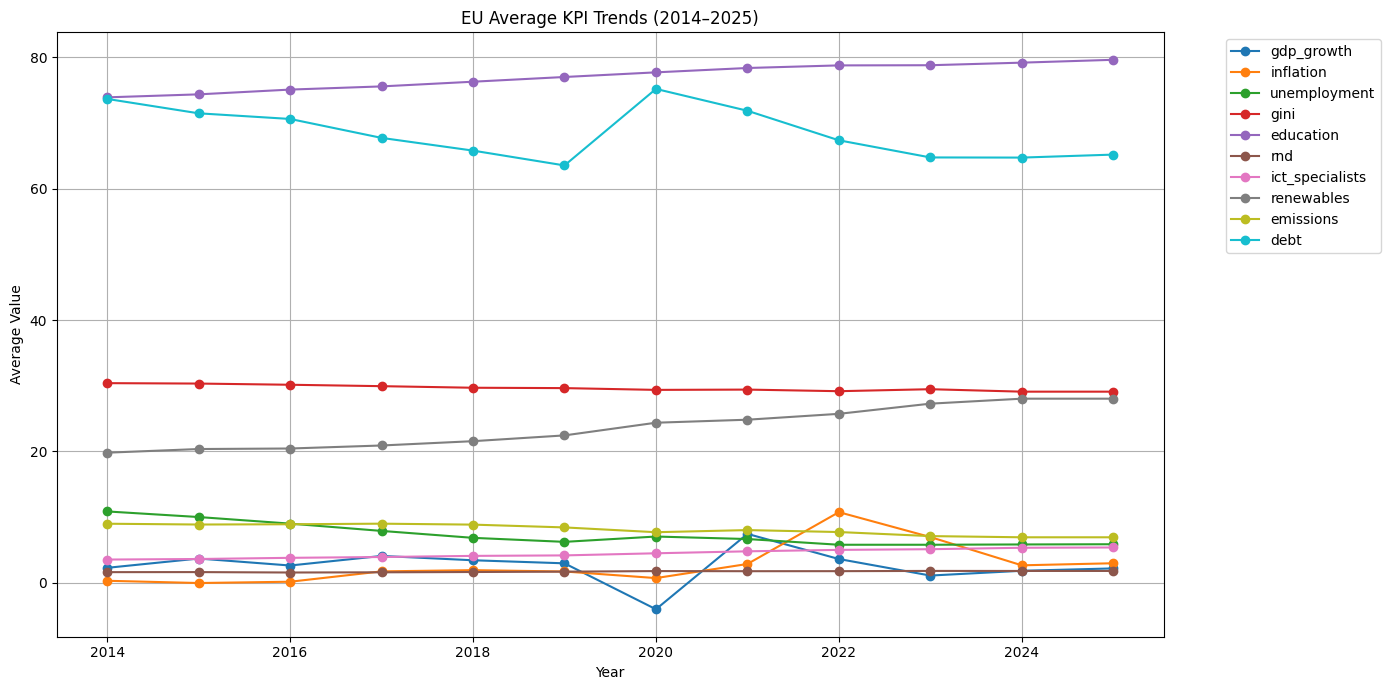

In [43]:
import matplotlib.pyplot as plt

# =========================================================
# EU AVERAGE KPI TRENDS OVER TIME
# =========================================================

# Compute yearly averages
yearly_trends = (
    eu_master_filled
    .groupby("year")
    .mean(numeric_only=True)
)

# Remove year itself if present
yearly_trends = yearly_trends.drop(columns=["year"], errors="ignore")

# Plot all KPIs
plt.figure(figsize=(14, 7))

for col in yearly_trends.columns:
    plt.plot(
        yearly_trends.index,
        yearly_trends[col],
        marker="o",
        label=col
    )

plt.title("EU Average KPI Trends (2014–2025)")
plt.xlabel("Year")
plt.ylabel("Average Value")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()

plt.show()

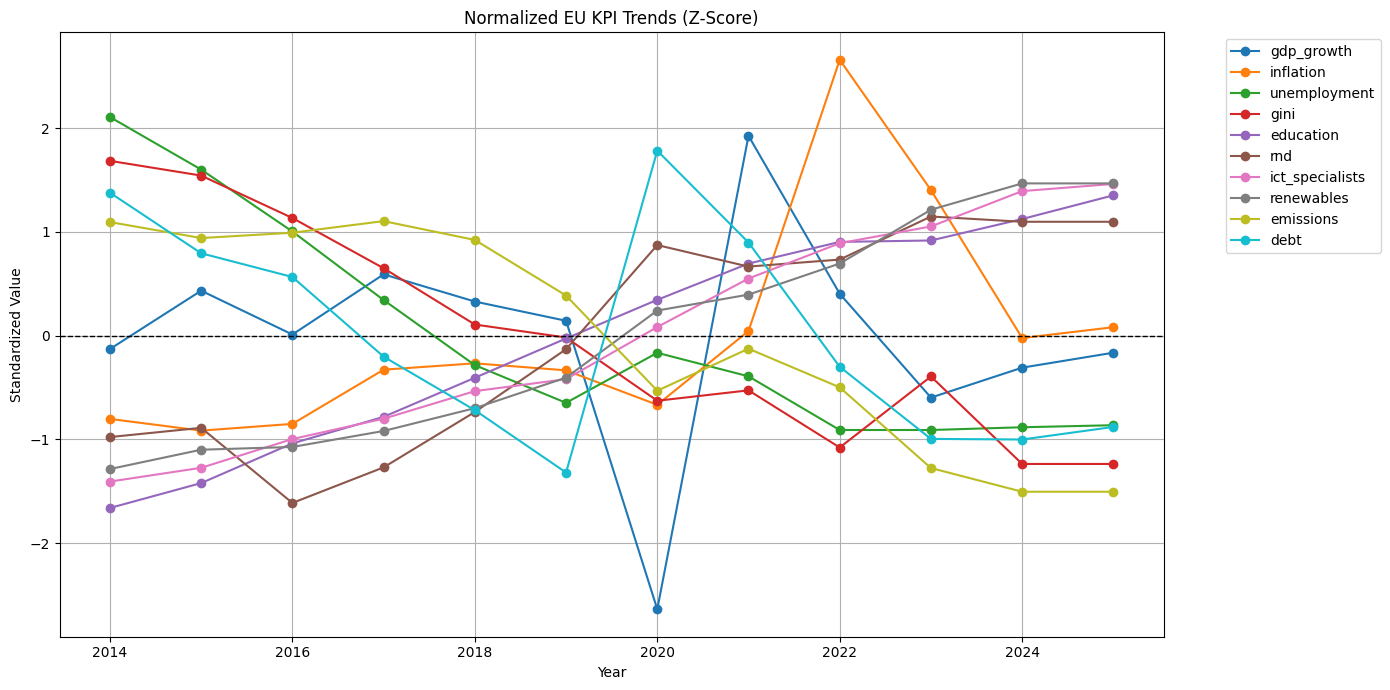

In [45]:
#normalized trends (since not all are changing)
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# NORMALIZE YEARLY KPI TRENDS
# =========================================================

# Standardize KPIs (z-score)
scaler = StandardScaler()

yearly_scaled = pd.DataFrame(
    scaler.fit_transform(yearly_trends),
    columns=yearly_trends.columns,
    index=yearly_trends.index
)

# Plot normalized trends
plt.figure(figsize=(14, 7))

for col in yearly_scaled.columns:
    plt.plot(
        yearly_scaled.index,
        yearly_scaled[col],
        marker="o",
        label=col
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Normalized EU KPI Trends (Z-Score)")
plt.xlabel("Year")
plt.ylabel("Standardized Value")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()

plt.show()

## Normalized EU KPI Trends (2014–2025)

To better compare KPI dynamics over time, all variables were standardized using z-score normalization.


::contentReference[oaicite:0]{index=0}


This transformation centers each KPI around its own historical average and scales it by its standard deviation, allowing comparison of relative trends despite different original units and magnitudes.

### Key Insights

#### Long-Term Structural Trends

Several indicators show strong long-term upward trends:

- ICT specialists
- Renewables share
- Education
- R&D expenditure

These trends suggest continued EU transition toward:

- digitalization
- innovation
- sustainability
- human capital development

At the same time, several indicators show long-term declines:

- Emissions
- Unemployment
- Debt (after post-COVID normalization)
- Slight reduction in Gini inequality

This may indicate gradual improvement in:

- labor market conditions
- environmental performance
- fiscal stabilization

---

### Major System Shocks

#### COVID-19 Shock (2020)

The pandemic created a clear structural break across the system:

- GDP growth collapsed sharply
- Public debt increased significantly
- Unemployment rose
- Emissions temporarily declined

#### Post-COVID Recovery (2021)

The recovery period shows:

- strong rebound in GDP growth
- beginning of debt normalization

#### Inflation Crisis (2022)

Inflation exhibited the strongest deviation in the dataset, reflecting the energy and macroeconomic crisis following the pandemic recovery period.

---

### Stable Structural Indicators

Some variables remained relatively stable over time:

- Gini inequality
- Education levels

These behave as slow-moving structural indicators rather than reactive macroeconomic variables.

---

### Potential Relationships

The normalized trends suggest several meaningful system relationships:

- Renewables ↑ while emissions ↓
- Education ↑ alongside ICT specialists ↑
- GDP growth and debt move inversely during crisis periods

These relationships may become useful later for:

- clustering analysis
- composite scoring
- resilience analysis
- policy tradeoff modeling

---

### Overall Interpretation

The dataset captures both:

- long-term structural transitions
- short-term macroeconomic shocks

This creates a strong analytical foundation for a systems-oriented EU decision and sustainability analysis rather than a purely descriptive macroeconomic study.

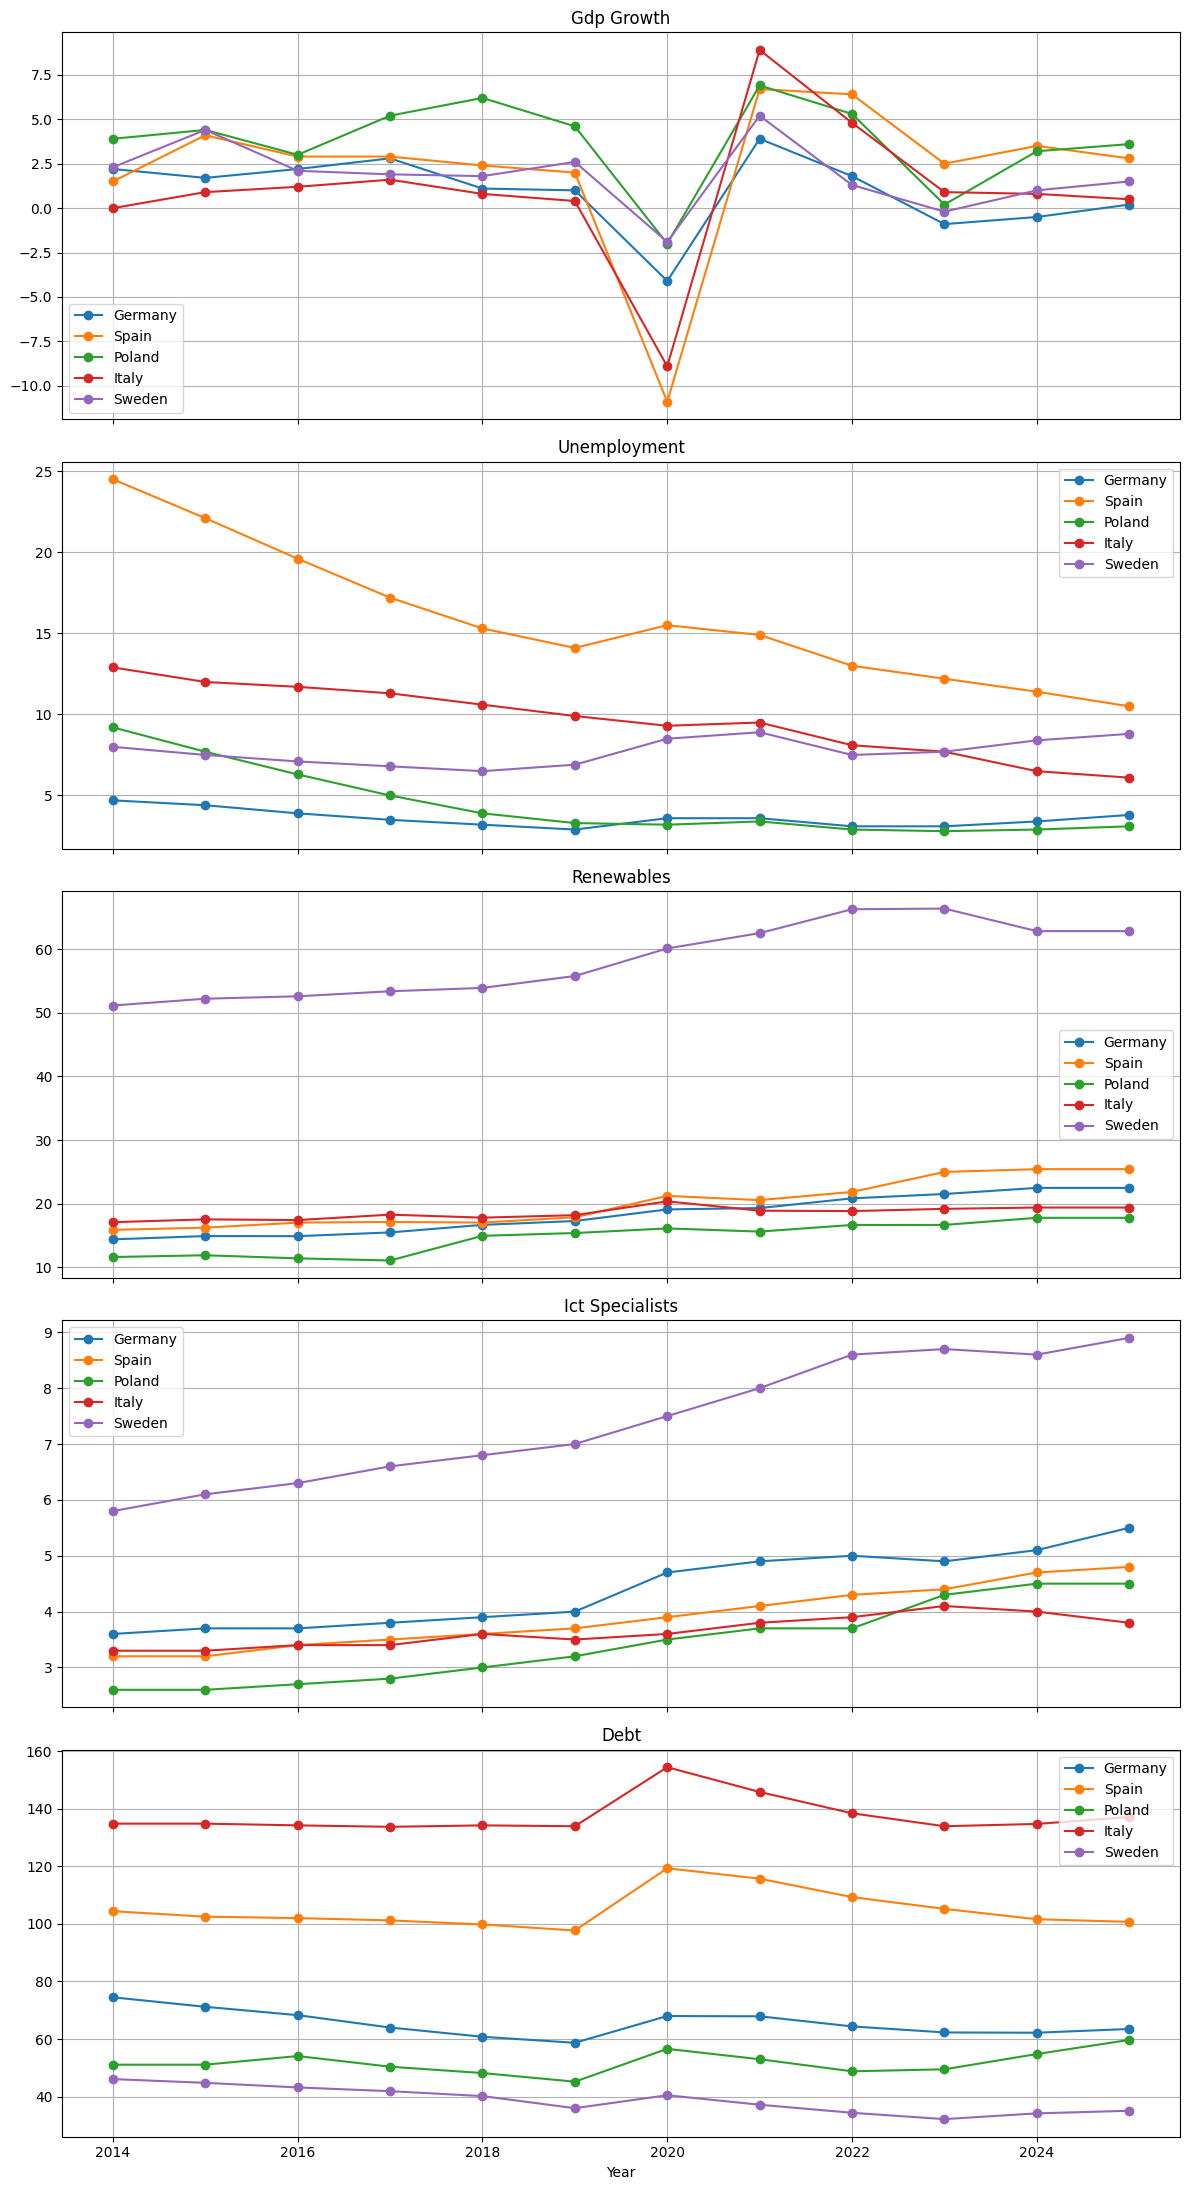

In [46]:
import matplotlib.pyplot as plt

# =========================================================
# COUNTRY COMPARISON — KEY KPI TRENDS
# =========================================================

# Selected countries for storytelling contrast
countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

# Selected KPIs
kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt"
]

# Create subplot grid
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 22),
    sharex=True
)

# Plot one KPI per subplot
for ax, kpi in zip(axes, kpis):

    for code, name in countries.items():

        temp = eu_master_filled[
            eu_master_filled["country"] == code
        ]

        ax.plot(
            temp["year"],
            temp[kpi],
            marker="o",
            label=name
        )

    ax.set_title(kpi.replace("_", " ").title())
    ax.grid(True)
    ax.legend()

# Global formatting
plt.xlabel("Year")
plt.tight_layout()

plt.show()

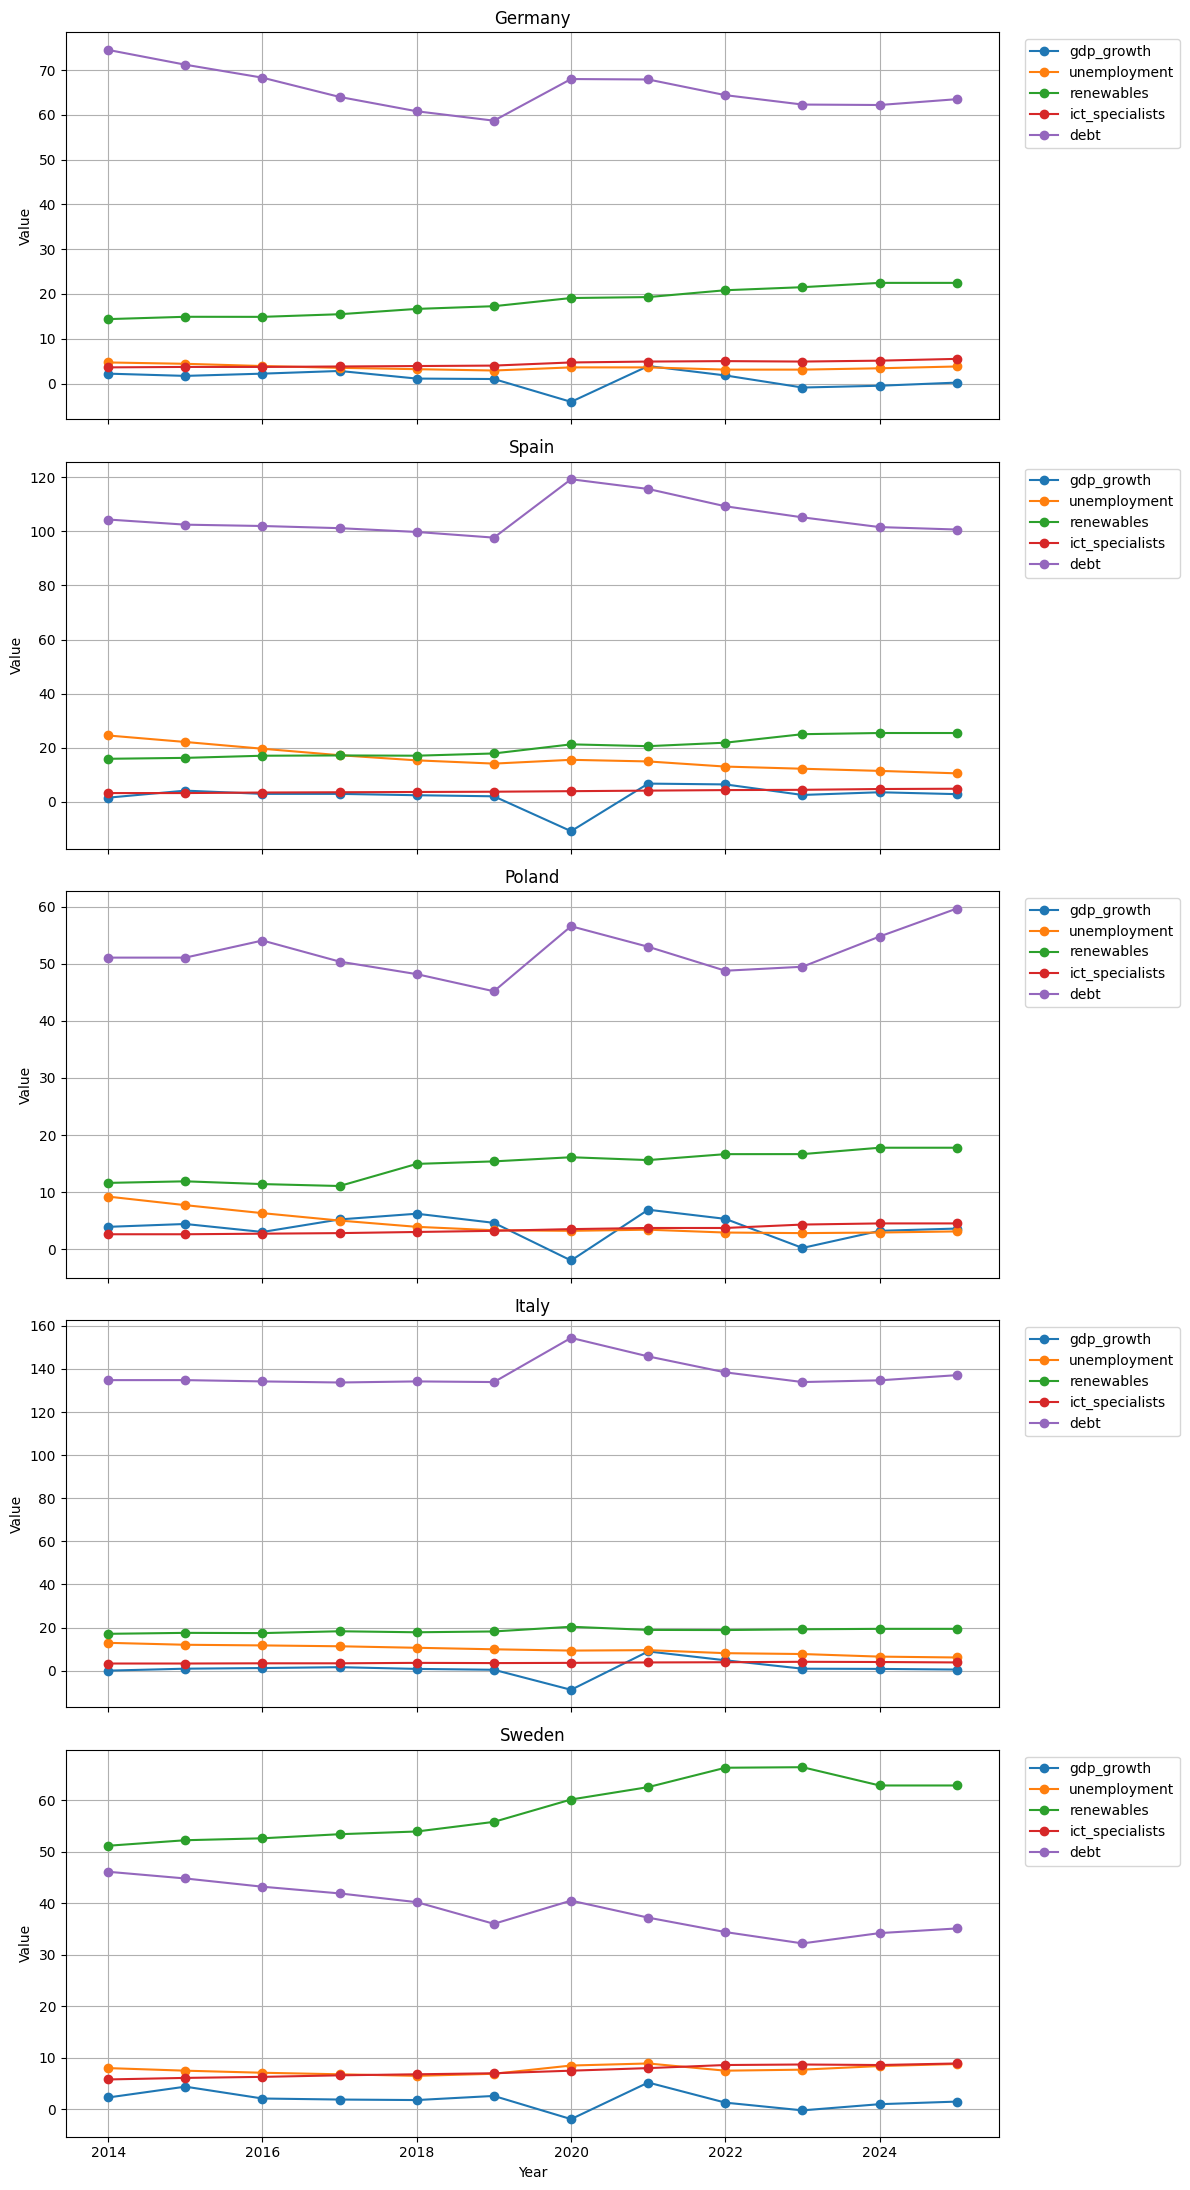

In [47]:
import matplotlib.pyplot as plt

# =========================================================
# COUNTRY PROFILES — ALL KEY KPIs PER COUNTRY
# =========================================================

countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt"
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 22),
    sharex=True
)

for ax, (code, name) in zip(axes, countries.items()):

    temp = eu_master_filled[
        eu_master_filled["country"] == code
    ].sort_values("year")

    for kpi in kpis:
        ax.plot(
            temp["year"],
            temp[kpi],
            marker="o",
            label=kpi
        )

    ax.set_title(name)
    ax.set_ylabel("Value")
    ax.grid(True)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.xlabel("Year")
plt.tight_layout()
plt.show()

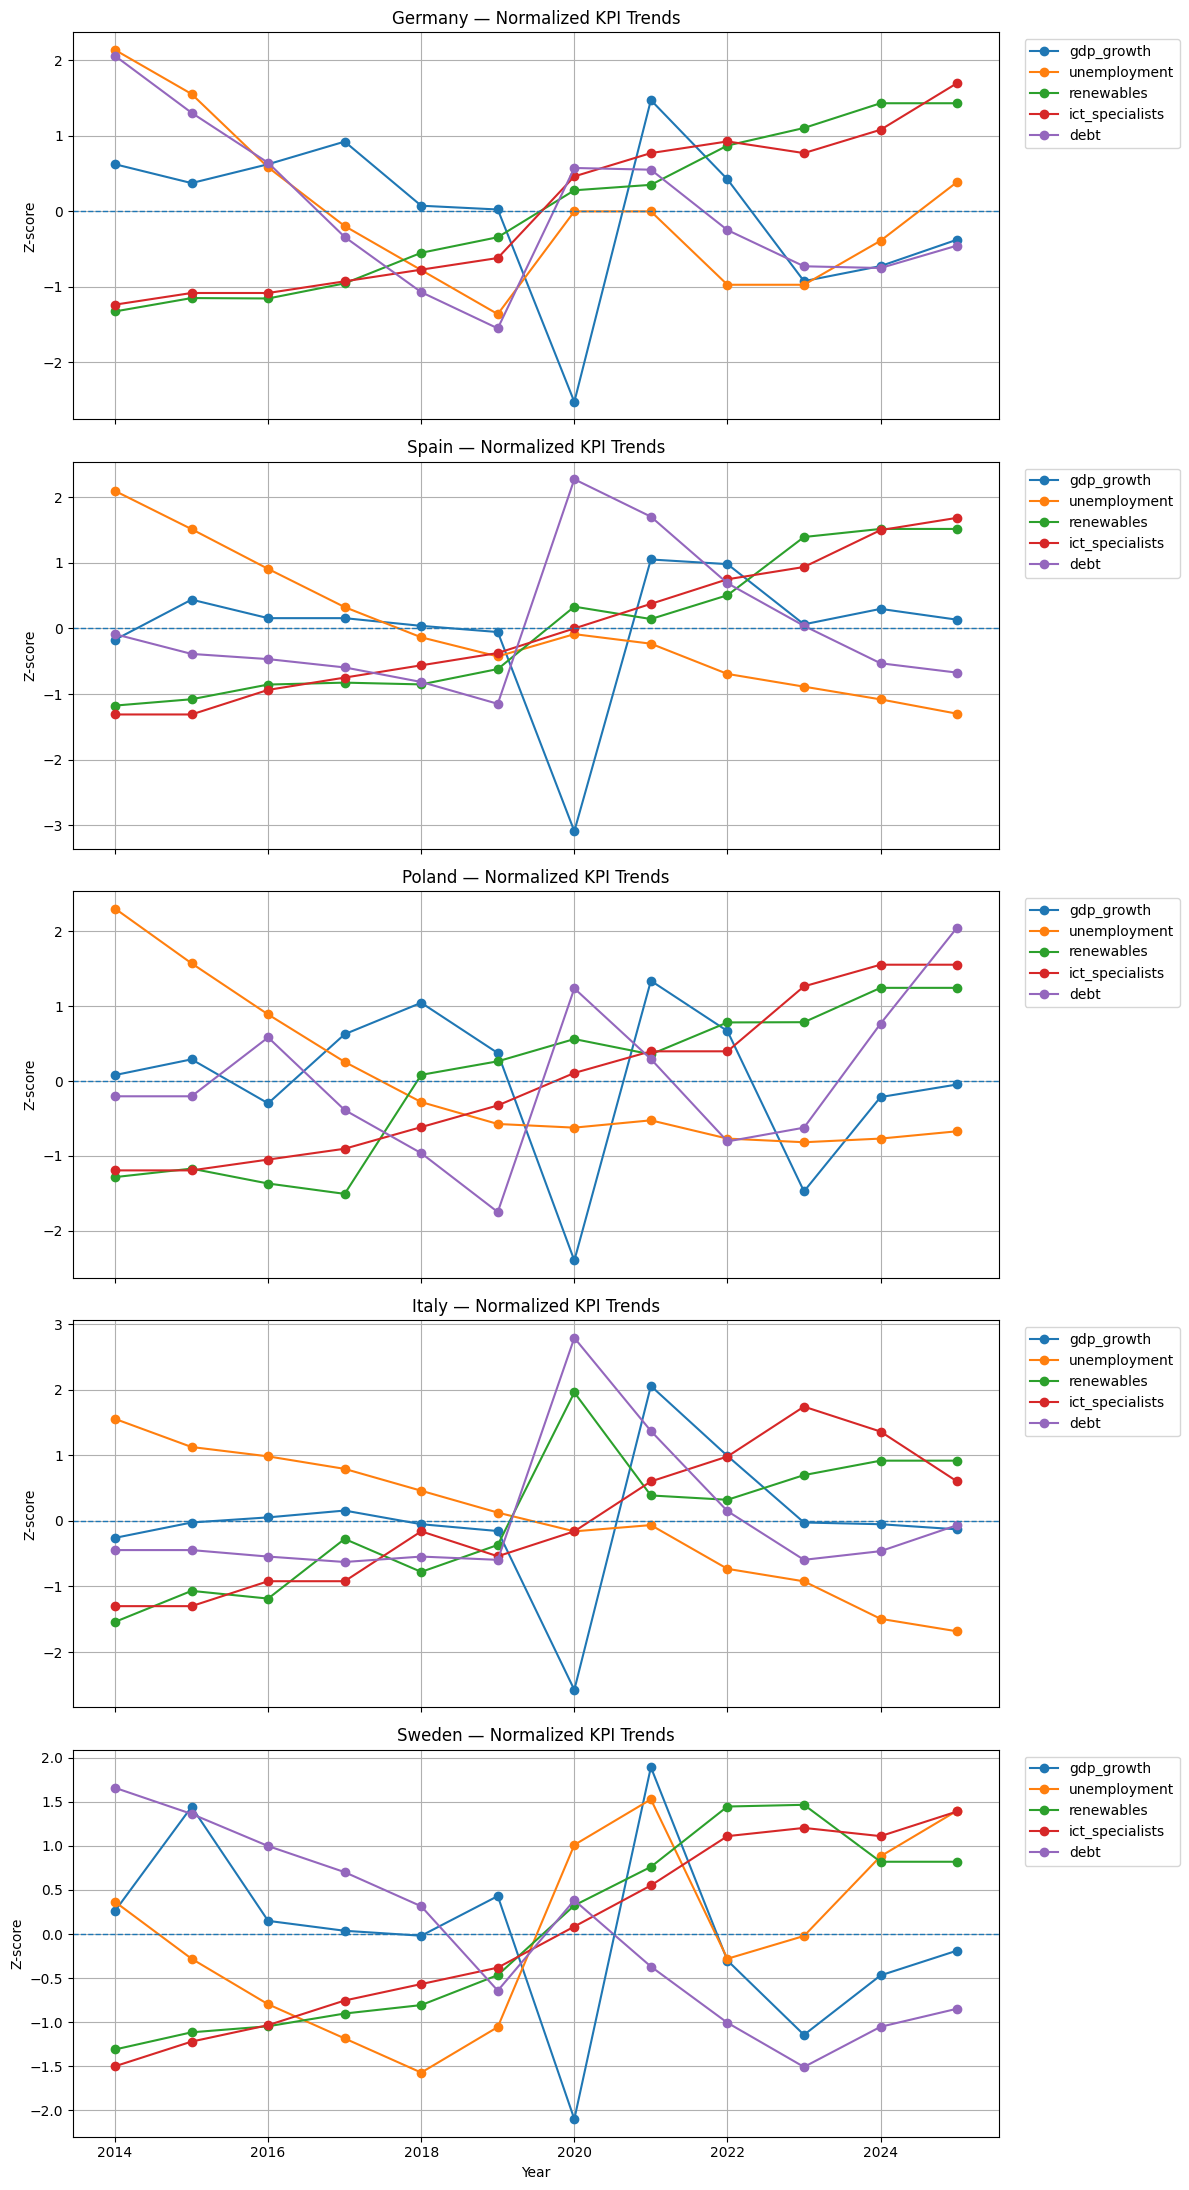

In [48]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# COUNTRY PROFILES — KPIs NORMALIZED WITHIN EACH COUNTRY
# =========================================================

countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt"
]

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 22),
    sharex=True
)

for ax, (code, name) in zip(axes, countries.items()):

    temp = (
        eu_master_filled[eu_master_filled["country"] == code]
        .sort_values("year")
        .copy()
    )

    # Normalize each KPI within the country across years
    scaler = StandardScaler()
    temp_scaled = pd.DataFrame(
        scaler.fit_transform(temp[kpis]),
        columns=kpis,
        index=temp["year"]
    )

    for kpi in kpis:
        ax.plot(
            temp_scaled.index,
            temp_scaled[kpi],
            marker="o",
            label=kpi
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{name} — Normalized KPI Trends")
    ax.set_ylabel("Z-score")
    ax.grid(True)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.xlabel("Year")
plt.tight_layout()
plt.show()

# Country Profiles — Absolute & Normalized Trends

## Germany — Stable Innovation-Led Economy

### Absolute Trends
- Low but relatively stable GDP growth
- Very low unemployment throughout the period
- Steady increase in renewables
- Strong ICT specialization growth
- Gradual reduction in debt after COVID spike

### Normalized Trends
- Clear post-2019 acceleration in ICT and renewables
- COVID shock visible but relatively short-lived
- Debt normalized downward quickly after crisis period
- Labor market remained structurally stable

### Interpretation
Germany represents a stable, high-capacity industrial economy transitioning steadily toward digitalization and sustainability while maintaining macroeconomic resilience.

---

## Spain — Recovery & Structural Adjustment Economy

### Absolute Trends
- Persistently high unemployment, though steadily declining
- Strong renewable energy expansion
- High debt burden
- Large GDP volatility during COVID and recovery

### Normalized Trends
- Strongest long-term unemployment improvement
- Significant ICT and renewables acceleration after 2020
- Severe COVID shock followed by strong rebound
- Debt remained elevated longer than peers

### Interpretation
Spain reflects a recovery-oriented economy improving structurally over time, but still carrying labor market and fiscal vulnerabilities.

---

## Poland — Fast-Growing Transition Economy

### Absolute Trends
- Strongest sustained GDP growth among the selected countries
- Rapid ICT and renewables growth
- Moderate debt levels
- Sharp decline in unemployment

### Normalized Trends
- Strong synchronized upward transition across:
  - ICT
  - renewables
  - labor market performance
- GDP remained relatively resilient during crises
- Debt became more volatile in recent years

### Interpretation
Poland represents a fast-converging transition economy combining growth, digitalization, and sustainability improvements simultaneously.

---

## Italy — Structurally Constrained Economy

### Absolute Trends
- Weak long-term GDP growth
- Very high and persistent debt
- Moderate renewable expansion
- Slow ICT growth
- Elevated unemployment

### Normalized Trends
- Strongest and most persistent debt spike after COVID
- ICT acceleration occurred later and more slowly
- Renewables improved inconsistently
- Structural weakness remained visible across most indicators

### Interpretation
Italy reflects a structurally constrained economy with persistent fiscal pressure and slower adaptation to digital and sustainability transitions.

---

## Sweden — Sustainability & Innovation Leader

### Absolute Trends
- Highest renewable energy share by far
- Strong ICT specialization
- Low debt trajectory
- Stable unemployment
- Moderate but resilient GDP performance

### Normalized Trends
- Continued acceleration in renewables despite already high baseline
- ICT remained consistently strong
- Debt steadily declined over time
- Overall system remained stable through crises

### Interpretation
Sweden represents a mature innovation-driven and sustainability-oriented economy with strong structural resilience and long-term policy consistency.

---

# Overall Comparative Insight

The comparison reveals distinct EU development archetypes:

- Germany → stable industrial innovation leader
- Spain → recovery and adjustment economy
- Poland → fast-growth convergence economy
- Italy → structurally constrained system
- Sweden → mature sustainability leader

The normalized trends are especially valuable because they reveal:
- transition speed
- crisis sensitivity
- structural direction
- recovery dynamics

rather than only absolute economic levels.

| Country | Absolute Trends | Normalized Trends | Interpretation |
|---|---|---|---|
| **Germany** | Low but stable GDP growth, very low unemployment, steady renewables growth, strong ICT increase, debt reduced after COVID | ICT and renewables accelerated after 2019, COVID shock temporary, debt normalized quickly, labor market remained stable | Stable industrial innovation leader with strong resilience and gradual sustainability transition |
| **Spain** | High but declining unemployment, strong renewables expansion, high debt burden, strong GDP volatility during COVID | Strongest unemployment improvement, strong post-2020 ICT and renewables acceleration, severe COVID shock, debt remained elevated | Recovery-oriented economy with improving structure but lingering labor and fiscal vulnerabilities |
| **Poland** | Strongest sustained GDP growth, rapid ICT and renewables growth, moderate debt, strong unemployment decline | Synchronized upward transition across growth, digitalization, and sustainability, relatively resilient GDP, more recent debt volatility | Fast-growing convergence economy undergoing rapid structural transition |
| **Italy** | Weak long-term GDP growth, very high debt, moderate renewables growth, slow ICT growth, elevated unemployment | Strongest persistent debt spike, delayed ICT acceleration, inconsistent sustainability transition, continued structural weakness | Structurally constrained economy with fiscal pressure and slower modernization dynamics |
| **Sweden** | Highest renewables share, strong ICT specialization, low debt trajectory, stable unemployment, resilient GDP | Continued renewables acceleration despite high baseline, strong ICT trajectory, steadily declining debt, highly stable system | Mature sustainability and innovation leader with strong structural resilience |

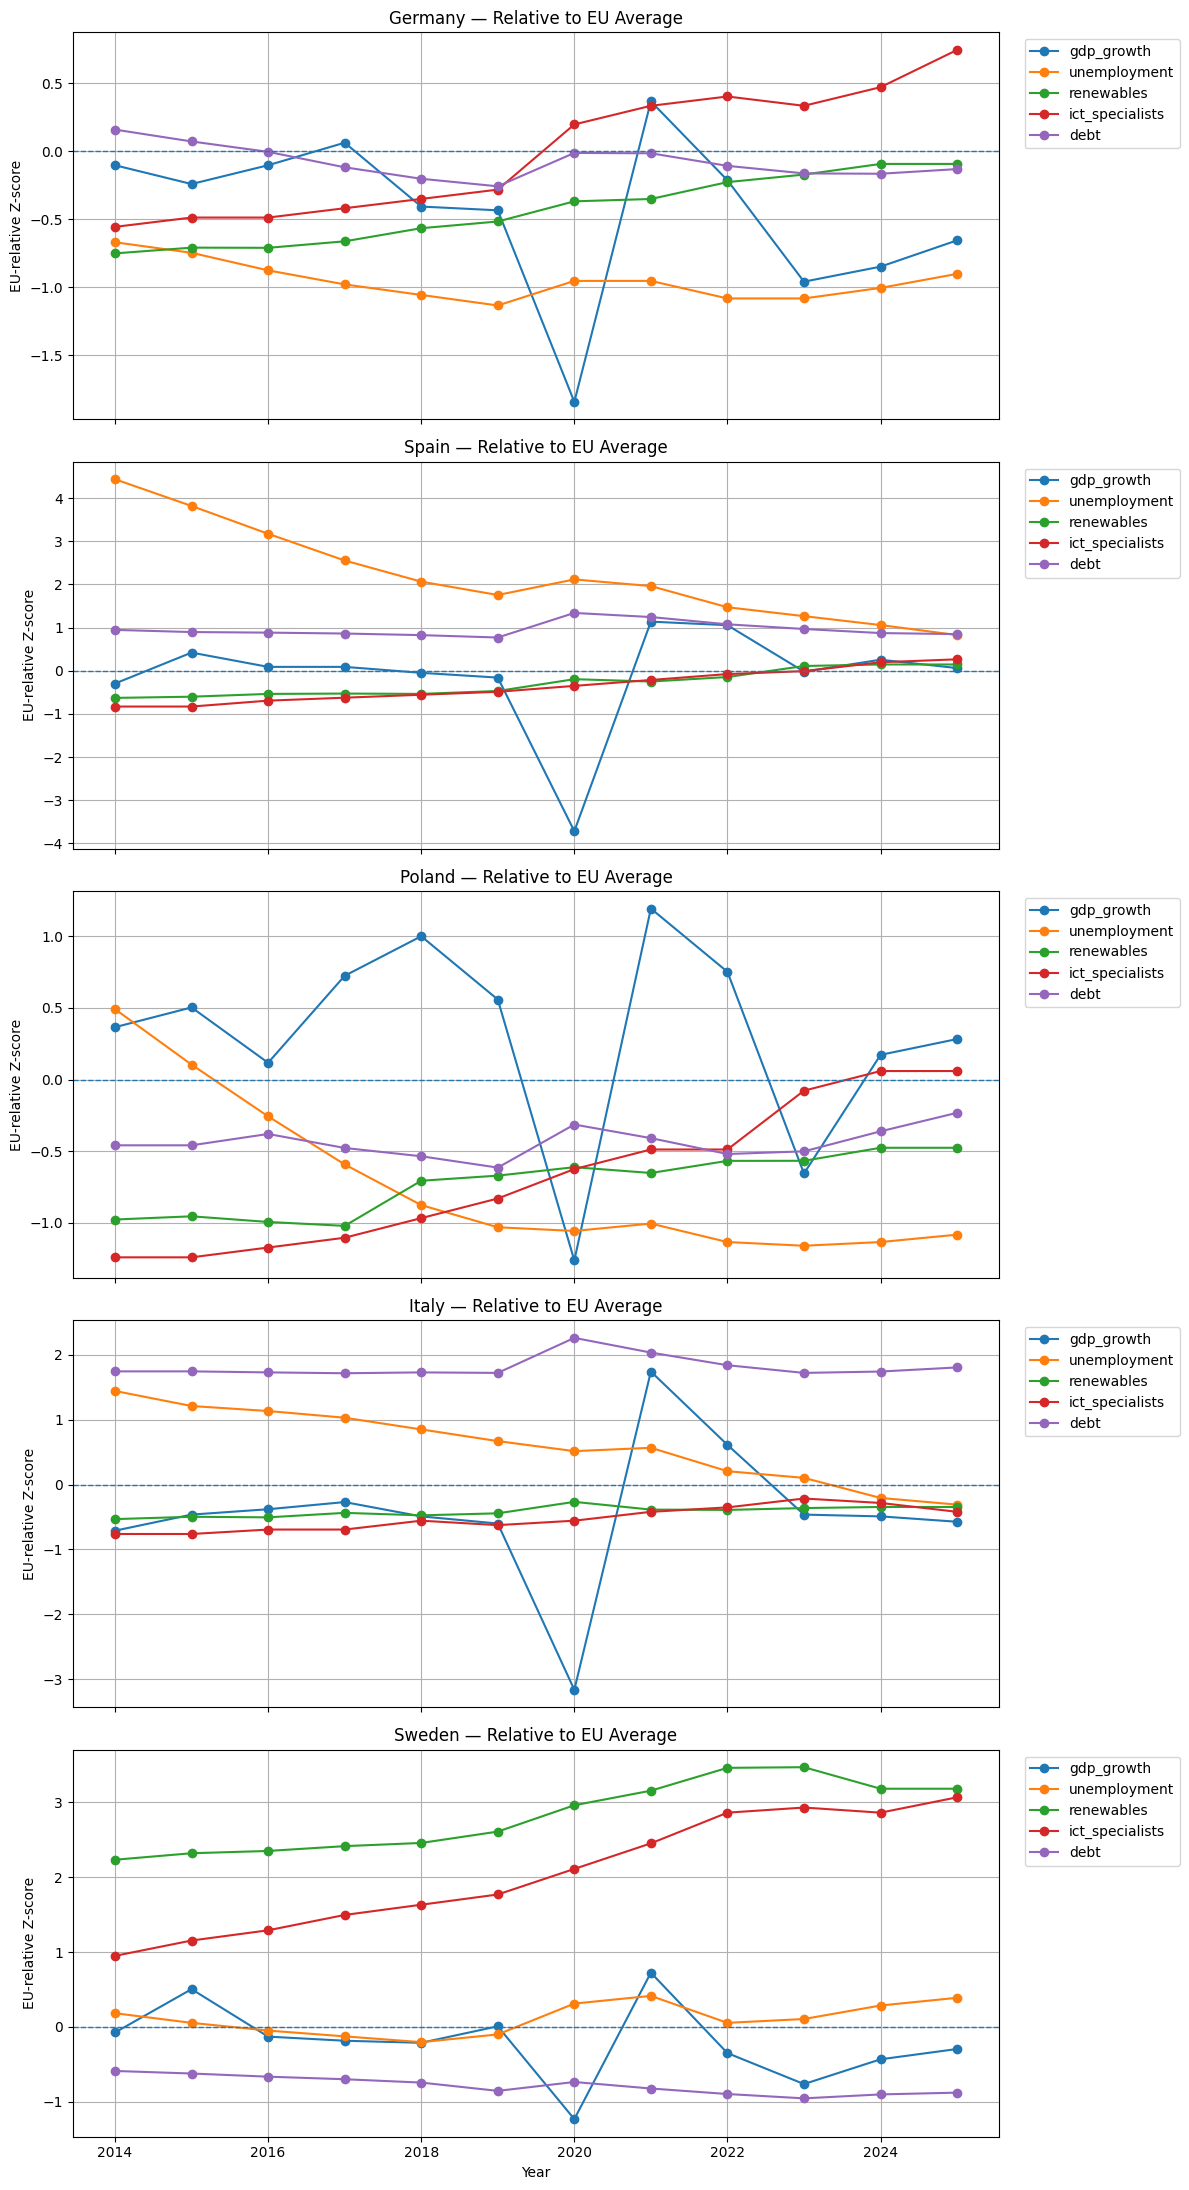

In [50]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# NORMALIZE USING EU-WIDE KPI DISTRIBUTION
# Each country is compared relative to the EU average
# =========================================================

countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt"
]

# ---------------------------------------------------------
# Fit scaler on ALL EU data
# ---------------------------------------------------------

scaler = StandardScaler()

scaler.fit(eu_master_filled[kpis])

# ---------------------------------------------------------
# Create subplots
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(12, 22),
    sharex=True
)

for ax, (code, name) in zip(axes, countries.items()):

    temp = (
        eu_master_filled[
            eu_master_filled["country"] == code
        ]
        .sort_values("year")
        .copy()
    )

    # Normalize relative to EU averages/std
    temp_scaled = pd.DataFrame(
        scaler.transform(temp[kpis]),
        columns=kpis,
        index=temp["year"]
    )

    for kpi in kpis:

        ax.plot(
            temp_scaled.index,
            temp_scaled[kpi],
            marker="o",
            label=kpi
        )

    ax.axhline(0, linestyle="--", linewidth=1)

    ax.set_title(f"{name} — Relative to EU Average")
    ax.set_ylabel("EU-relative Z-score")

    ax.grid(True)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

plt.xlabel("Year")

plt.tight_layout()

plt.show()

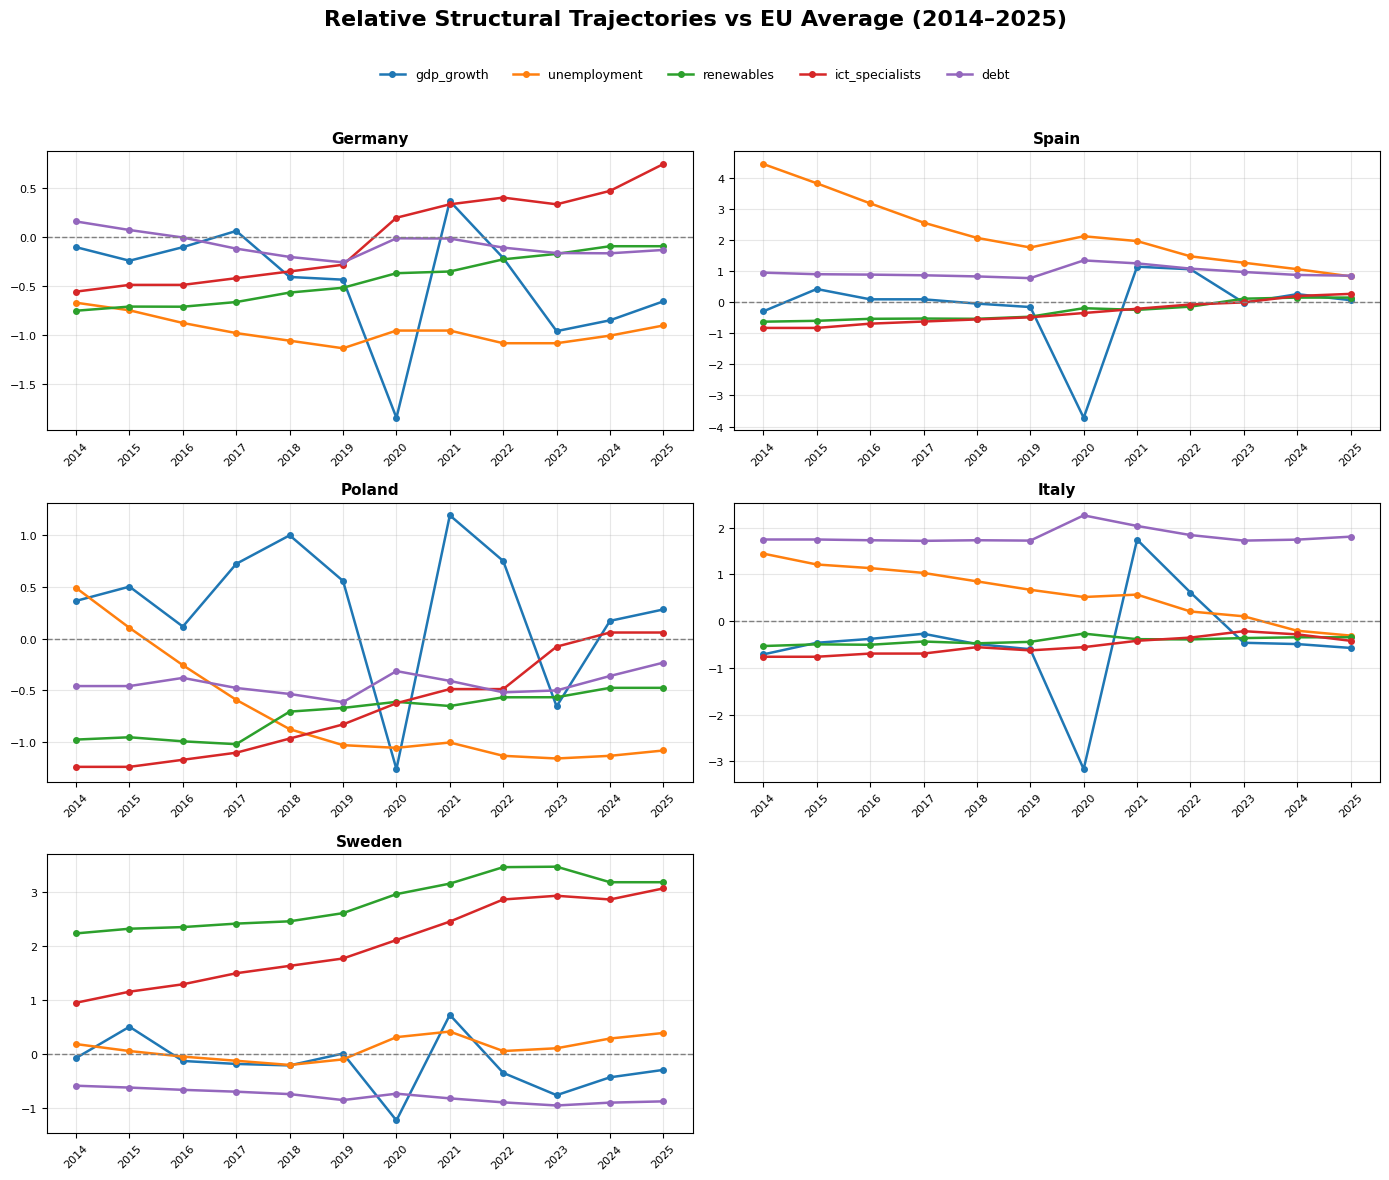

In [74]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# NORMALIZE USING EU-WIDE KPI DISTRIBUTION
# Each country is compared relative to the EU average
# =========================================================

countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt"
]

# ---------------------------------------------------------
# Fit scaler on ALL EU data
# ---------------------------------------------------------

scaler = StandardScaler()

scaler.fit(eu_master_filled[kpis])

# ---------------------------------------------------------
# COMPACT 2-COLUMN LAYOUT
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12),
    sharex=False   # changed
)

axes = axes.flatten()

for i, (code, name) in enumerate(countries.items()):

    ax = axes[i]

    temp = (
        eu_master_filled[
            eu_master_filled["country"] == code
        ]
        .sort_values("year")
        .copy()
    )

    # Normalize relative to EU averages/std
    temp_scaled = pd.DataFrame(
        scaler.transform(temp[kpis]),
        columns=kpis,
        index=temp["year"]
    )

    for kpi in kpis:

        ax.plot(
            temp_scaled.index,
            temp_scaled[kpi],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=kpi
        )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        color="gray"
    )

    ax.set_title(
        f"{name}",
        fontsize=11,
        fontweight="bold"
    )

    # SHOW YEARS ON ALL PLOTS
    ax.set_xticks(temp_scaled.index)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

    ax.tick_params(axis="y", labelsize=8)

    ax.grid(alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[-1])

# ---------------------------------------------------------
# GLOBAL TITLE
# ---------------------------------------------------------

fig.suptitle(
    "Relative Structural Trajectories vs EU Average (2014–2025)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# ---------------------------------------------------------
# SHARED LEGEND
# ---------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=5,
    fontsize=9,
    frameon=False
)

# ---------------------------------------------------------
# SPACING
# ---------------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

# Country Profiles — Relative to EU Average (Normalized by EU Distribution)

This visualization compares each country relative to the overall EU system rather than relative to its own historical baseline.

Interpretation:

- `0` = EU average
- Positive values = above EU average
- Negative values = below EU average

This reveals:
- structural leadership
- convergence/divergence
- relative strengths and weaknesses
- transition speed compared to Europe

---

## Germany — Stable Above-Average Innovation Economy

### Key Observations
- ICT specialists moved from slightly below EU average to clearly above average over time
- Debt remained consistently below EU average after COVID normalization
- Unemployment remained well below EU average throughout the period
- Renewables improved steadily but stayed slightly below leading EU performers
- GDP growth remained relatively modest compared to faster-growing economies

### Interpretation
Germany appears as a stable and fiscally disciplined innovation economy with strong labor-market performance, though less dynamic in growth and sustainability acceleration than some transition economies.

---

## Spain — Recovery Economy with Structural Labor Challenges

### Key Observations
- Unemployment remained far above EU average despite strong improvement over time
- Debt consistently remained above EU average
- Renewables and ICT gradually converged toward EU average
- GDP growth showed high volatility, especially during COVID and recovery periods

### Interpretation
Spain demonstrates gradual structural convergence toward the EU average while still carrying persistent labor-market and fiscal vulnerabilities.

---

## Poland — Fast-Converging Growth Economy

### Key Observations
- GDP growth remained consistently above EU average
- Unemployment moved from above-average levels to significantly below EU average
- ICT specialists improved steadily toward EU average
- Debt stayed below EU average
- Renewables remained below EU average despite gradual improvement

### Interpretation
Poland represents one of the strongest convergence stories in the dataset, combining rapid growth, labor-market improvement, and increasing digitalization while maintaining relatively low debt.

---

## Italy — Structurally Constrained Economy

### Key Observations
- Debt remained dramatically above EU average throughout the entire period
- GDP growth stayed below EU average except during temporary rebound periods
- ICT specialists consistently remained below EU average
- Renewables stayed slightly below EU average
- Unemployment improved gradually toward EU average

### Interpretation
Italy shows persistent structural constraints characterized by low growth, weak digitalization, and extremely high debt burden relative to the broader EU system.

---

## Sweden — Sustainability & Digitalization Leader

### Key Observations
- Renewables remained far above EU average and continued increasing
- ICT specialists stayed strongly above EU average
- Debt remained consistently below EU average
- Unemployment stayed near or slightly above EU average
- GDP growth remained relatively stable around EU average

### Interpretation
Sweden clearly stands out as the strongest sustainability and digitalization leader in the comparison, combining innovation leadership with strong fiscal stability.

---

# Overall Comparative Insight

The EU-relative normalization reveals clear structural archetypes:

| Archetype | Country |
|---|---|
| Stable innovation leader | Germany |
| Recovery & adjustment economy | Spain |
| Fast convergence economy | Poland |
| Structurally constrained system | Italy |
| Sustainability & digital leader | Sweden |

Compared to country-internal normalization, this approach better highlights:
- structural positioning inside the EU system
- relative competitiveness
- long-term convergence/divergence
- policy and transition leadership
- systemic inequality between member states

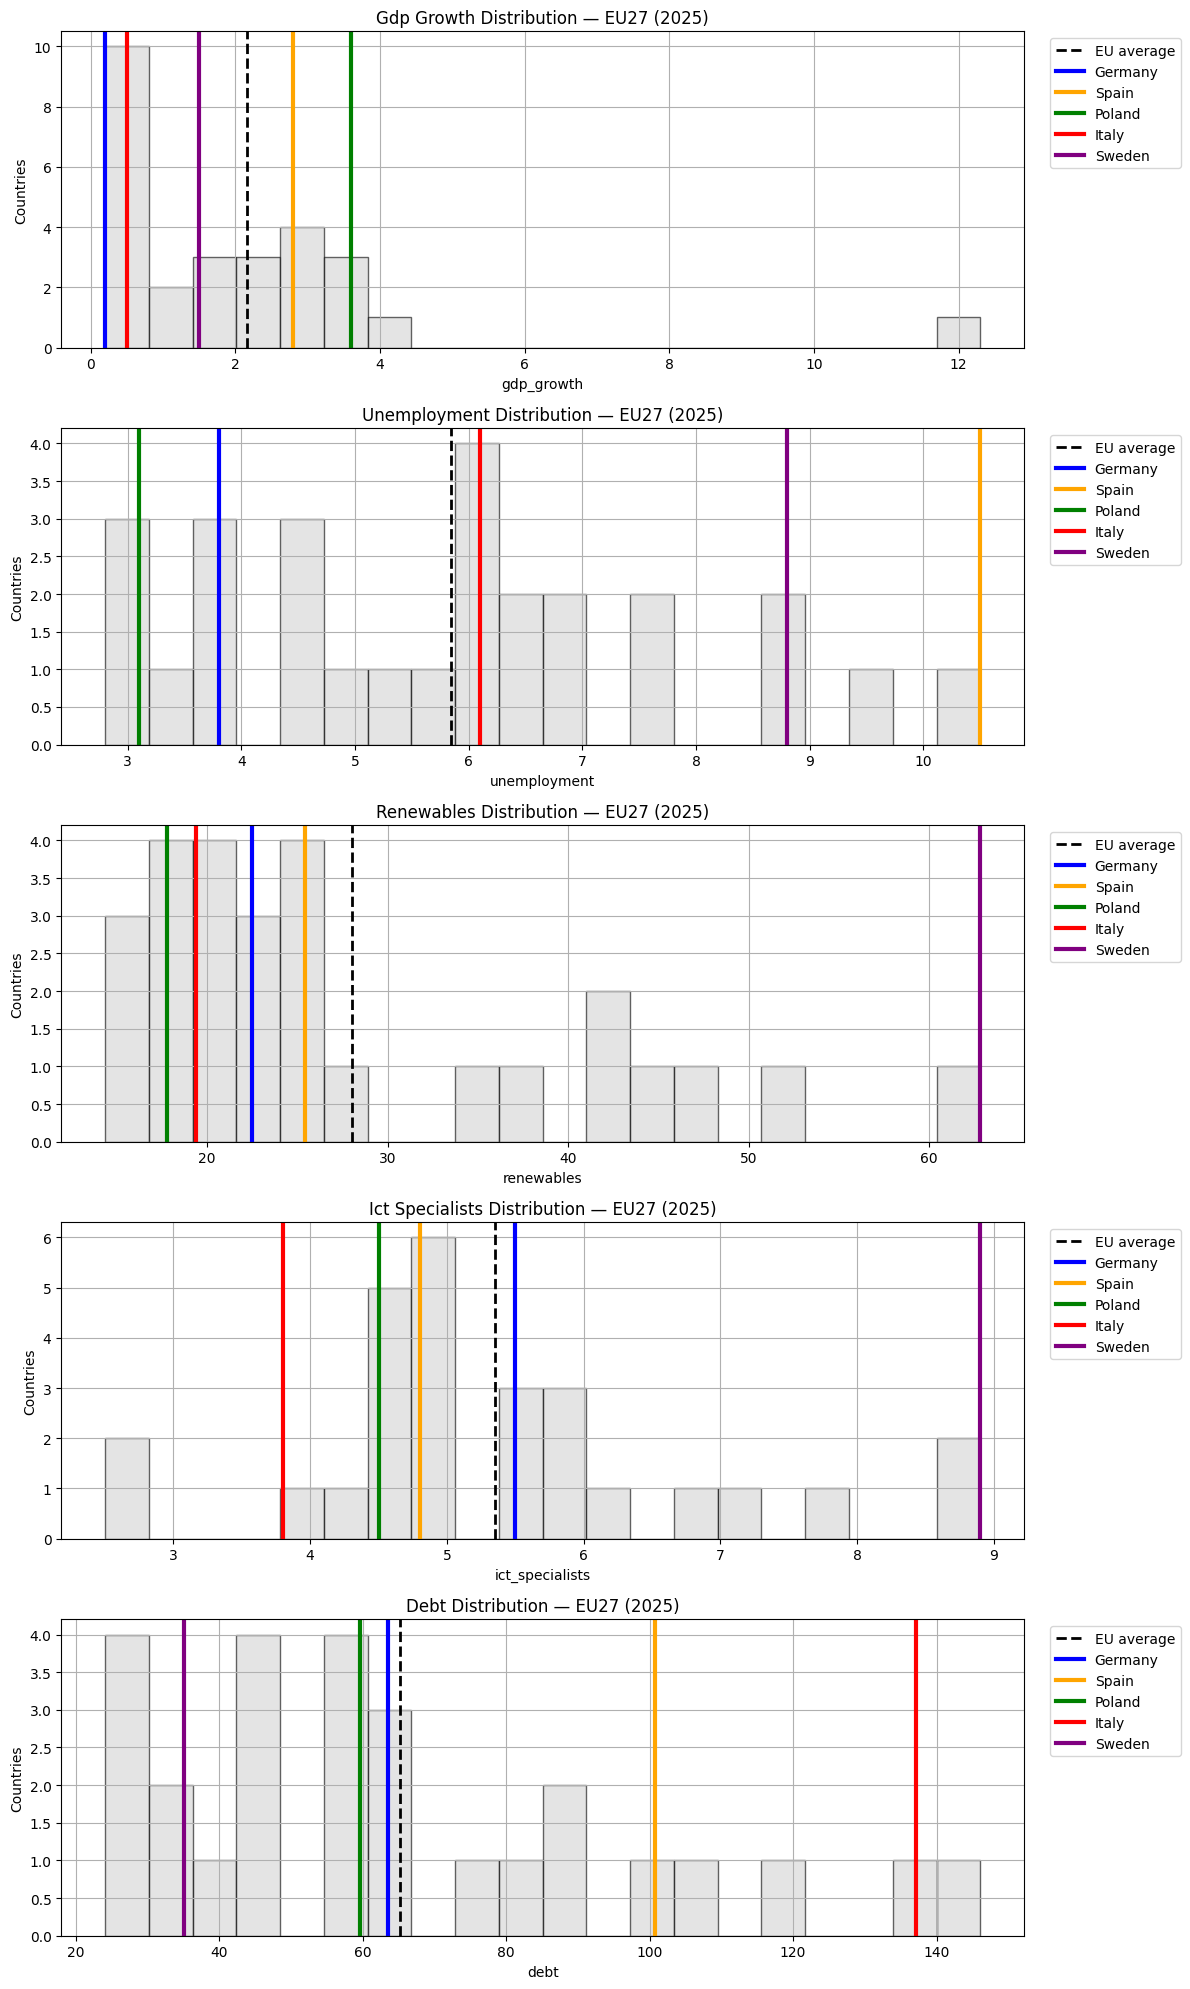

In [52]:
import matplotlib.pyplot as plt

# =========================================================
# EU KPI DISTRIBUTIONS + HIGHLIGHTED COUNTRIES
# =========================================================

highlight_countries = {
    "DE": ("Germany", "blue"),
    "ES": ("Spain", "orange"),
    "PL": ("Poland", "green"),
    "IT": ("Italy", "red"),
    "SE": ("Sweden", "purple")
}

kpis = [
    "gdp_growth",
    "unemployment",
    "renewables",
    "ict_specialists",
    "debt"
]

year_to_plot = 2025

data_year = eu_master_filled[
    eu_master_filled["year"] == year_to_plot
]

fig, axes = plt.subplots(
    nrows=len(kpis),
    ncols=1,
    figsize=(12, 20)
)

for ax, kpi in zip(axes, kpis):

    # EU distribution histogram
    ax.hist(
        data_year[kpi],
        bins=20,          # smaller bins
        alpha=0.6,
        color="lightgray",
        edgecolor="black"
    )

    # EU average line
    eu_avg = data_year[kpi].mean()

    ax.axvline(
        eu_avg,
        color="black",
        linestyle="--",
        linewidth=2,
        label="EU average"
    )

    # Highlight countries
    for code, (name, color) in highlight_countries.items():

        value = data_year.loc[
            data_year["country"] == code,
            kpi
        ].values[0]

        ax.axvline(
            value,
            color=color,
            linewidth=3,
            label=name
        )

    ax.set_title(
        f"{kpi.replace('_', ' ').title()} Distribution — EU27 ({year_to_plot})"
    )

    ax.set_xlabel(kpi)
    ax.set_ylabel("Countries")

    ax.grid(True)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.tight_layout()

plt.show()

Preliminary exploration already shows:

- strong long-term structural transitions across the EU
- clear responses to major macroeconomic shocks
- meaningful differences between country development trajectories

This suggests the dataset contains sufficient temporal, structural, and cross-country variation to support deeper systems-oriented analysis later in the project.

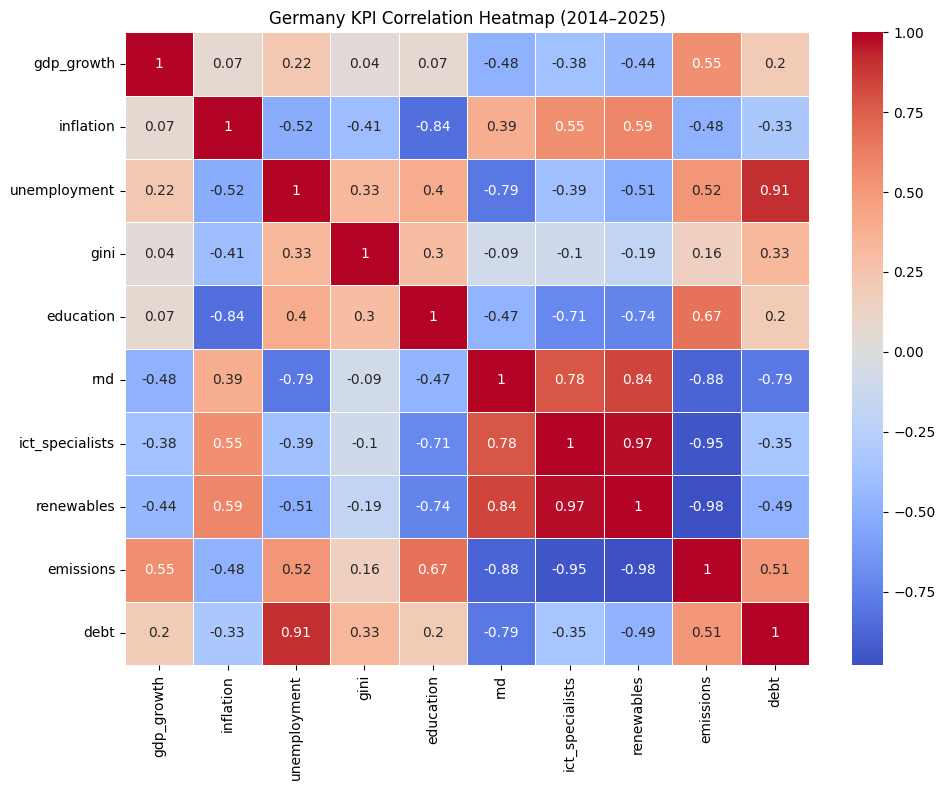

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# GERMANY KPI CORRELATION HEATMAP
# =========================================================

# Filter Germany data
germany = (
    eu_master_filled[
        eu_master_filled["country"] == "DE"
    ]
    .drop(columns=["country", "year"])
)

# Correlation matrix
corr = germany.corr().round(2)

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Germany KPI Correlation Heatmap (2014–2025)")

plt.tight_layout()
plt.show()

## Germany — Preliminary Correlation Observations

### Strong Structural Transition Cluster

The strongest pattern is the tight positive relationship between:

- ICT specialists
- renewables
- R&D

Examples:
- ICT ↔ renewables = 0.97
- R&D ↔ renewables = 0.84
- R&D ↔ ICT = 0.78

This suggests Germany’s digitalization, innovation, and sustainability transitions may be evolving together as part of a broader structural transformation.

---

### Sustainability vs Emissions

Very strong negative correlations appear between:

- renewables ↔ emissions = -0.98
- ICT ↔ emissions = -0.95
- R&D ↔ emissions = -0.88

This may indicate that higher innovation and sustainability adoption are associated with lower emissions intensity over time.

---

### Labor Market & Debt Relationship

A strong positive relationship exists between:

- unemployment ↔ debt = 0.91

This reflects macroeconomic stress dynamics:
higher unemployment periods tend to coincide with higher fiscal pressure and debt accumulation.

---

### Education Dynamics

Education shows:
- positive relation with emissions reduction
- negative relation with ICT and renewables

This is likely influenced by:
- limited sample size
- strong time-trend effects
- gradual structural changes over time

Interpret cautiously.

---

### GDP Growth Appears Less Structurally Coupled

GDP growth correlations are relatively weaker and mixed.

This may suggest:
- short-term cyclical behavior
- crisis sensitivity
- less stable long-term alignment with structural indicators.

---

## Important Caveat

These are preliminary exploratory correlations only.

Because:
- sample size is small (12 years)
- many variables trend over time simultaneously
- correlations may partially reflect shared temporal trends rather than causal relationships

Still, the heatmap already suggests:
- meaningful system structure
- interacting transitions
- interpretable macroeconomic dynamics

which supports the depth and analytical potential of the dataset.

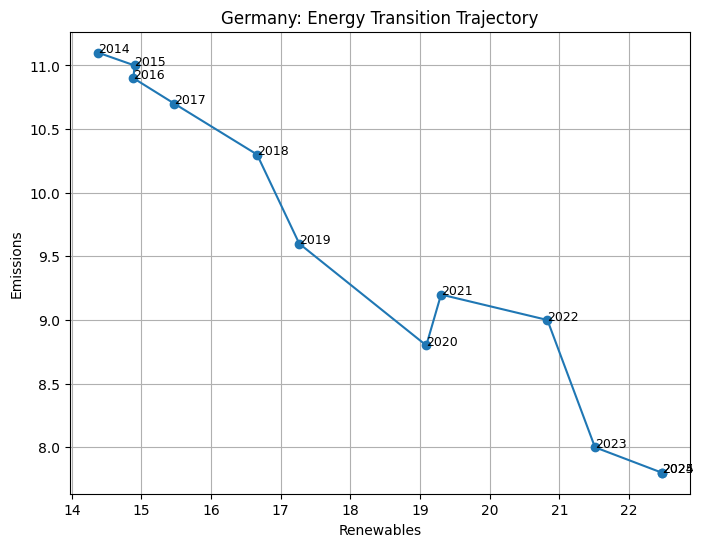

In [55]:
# Germany subset
germany = (
    eu_master_filled[
        eu_master_filled["country"] == "DE"
    ]
    .sort_values("year")
)

# Plot trajectory
plt.figure(figsize=(8, 6))

plt.plot(
    germany["renewables"],
    germany["emissions"],
    marker="o"
)

# Add year labels
for i, year in enumerate(germany["year"]):

    plt.text(
        germany["renewables"].iloc[i],
        germany["emissions"].iloc[i],
        str(year),
        fontsize=9
    )

plt.xlabel("Renewables")
plt.ylabel("Emissions")

plt.title("Germany: Energy Transition Trajectory")

plt.grid(True)

plt.show()

## Germany — Energy Transition Trajectory

The trajectory plot shows Germany’s movement through sustainability space over time using:

- x-axis → renewables share
- y-axis → emissions level

Key observations:

- From 2014–2019:
  renewables gradually increased while emissions steadily declined, suggesting a relatively smooth sustainability transition.

- 2020 creates a visible structural disruption:
  emissions dropped sharply during the COVID period while renewables continued increasing.

- 2021–2022 show partial rebound and instability:
  emissions temporarily increased again despite continued renewable growth, likely reflecting post-pandemic economic recovery and energy-system stress.

- From 2023 onward:
  the trajectory resumes a stronger transition direction with:
  - higher renewable penetration
  - substantially lower emissions

Overall, the plot suggests Germany experienced a long-term structural sustainability transition rather than isolated short-term fluctuations.

In [63]:
import pandas as pd

# =========================================================
# 1. LOAD GOVERNMENT EXPENDITURE TSV
# =========================================================

file_path = r"C:\Users\gilad\Documents\Data Analytics course 02_26\capston project\possible data\raw\eurostat\government_expenditure.tsv"

gov_raw = pd.read_csv(file_path, sep="\t")

print("Raw shape:", gov_raw.shape)
display(gov_raw.head())


# =========================================================
# 2. SPLIT EUROSTAT METADATA COLUMN
# =========================================================

meta_col = gov_raw.columns[0]

gov = gov_raw.copy()

gov[
    ["freq", "unit", "sector", "cofog99", "na_item", "country"]
] = gov[meta_col].str.split(",", expand=True)

gov = gov.drop(columns=[meta_col])


# =========================================================
# 3. CONVERT WIDE YEARS TO LONG FORMAT
# =========================================================

gov_long = gov.melt(
    id_vars=["freq", "unit", "sector", "cofog99", "na_item", "country"],
    var_name="year",
    value_name="value"
)

gov_long["year"] = gov_long["year"].astype(int)


# =========================================================
# 4. CLEAN VALUES
# Eurostat values may contain flags like "54.1 p" or ":"
# =========================================================

gov_long["value"] = (
    gov_long["value"]
    .astype(str)
    .str.replace(":", "", regex=False)
    .str.replace(" p", "", regex=False)
    .str.replace(" e", "", regex=False)
    .str.strip()
)

gov_long["value"] = pd.to_numeric(gov_long["value"], errors="coerce")


# =========================================================
# 5. FILTER ONLY WHAT WE NEED
# Unit: % of GDP
# Sector: General government
# na_item: Total expenditure
# COFOG: selected strategic spending domains
# =========================================================

keep_cofog = [
    "TOTAL",  # total government expenditure
    "GF02",   # defence
    "GF04",   # economic affairs
    "GF05",   # environmental protection
    "GF07",   # health
    "GF09",   # education
    "GF10"    # social protection
]

gov_long_filtered = gov_long[
    (gov_long["unit"] == "PC_GDP") &
    (gov_long["sector"] == "S13") &
    (gov_long["na_item"] == "TE") &
    (gov_long["cofog99"].isin(keep_cofog))
].copy()


# =========================================================
# 6. PIVOT TO WIDE FORMAT
# =========================================================

gov_wide = (
    gov_long_filtered
    .pivot_table(
        index=["country", "year"],
        columns="cofog99",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

gov_wide.columns.name = None


# =========================================================
# 7. RENAME COLUMNS
# =========================================================

gov_wide = gov_wide.rename(columns={
    "TOTAL": "total_gov_expenditure",
    "GF02": "defense_spending",
    "GF04": "economic_affairs_spending",
    "GF05": "environment_spending",
    "GF07": "health_spending",
    "GF09": "education_spending",
    "GF10": "social_protection_spending"
})


# =========================================================
# 8. VALIDATE
# =========================================================

print("Clean wide shape:", gov_wide.shape)

display(gov_wide.head())

display(
    gov_wide.isna().sum().sort_values(ascending=False)
)

display(
    gov_wide.columns
)


# =========================================================
# 9. MERGE WITH MAIN EU DATASET
# =========================================================

eu_master_plus = eu_master_filled.merge(
    gov_wide,
    on=["country", "year"],
    how="left"
)

print("Merged shape:", eu_master_plus.shape)

display(eu_master_plus.head())

display(
    eu_master_plus.isna().sum().sort_values(ascending=False)
)

Raw shape: (1320, 13)


,"freq,unit,sector,cofog99,na_item,geo\TIME_PERIOD",2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"A,PC_GDP,S13,GF01,D3,AT",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,:
1,"A,PC_GDP,S13,GF01,D3,BE",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0 p,:
2,"A,PC_GDP,S13,GF01,D3,BG",: m,: m,: m,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,:
3,"A,PC_GDP,S13,GF01,D3,CH",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,:
4,"A,PC_GDP,S13,GF01,D3,CY",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,:


Clean wide shape: (331, 9)


,country,year,defense_spending,economic_affairs_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
0,AT,2014,0.6,7.0,0.4,8.2,5.0,21.4,52.4
1,AT,2015,0.6,6.0,0.4,8.3,5.0,21.3,51.2
2,AT,2016,0.6,5.9,0.4,8.3,4.9,21.1,50.6
3,AT,2017,0.6,6.1,0.4,8.3,4.9,20.7,49.8
4,AT,2018,0.6,6.0,0.4,8.3,4.8,20.3,49.2


environment_spending          1
social_protection_spending    1
economic_affairs_spending     1
education_spending            1
health_spending               1
total_gov_expenditure         1
country                       0
year                          0
defense_spending              0
dtype: int64

Index(['country', 'year', 'defense_spending', 'economic_affairs_spending',
       'environment_spending', 'health_spending', 'education_spending',
       'social_protection_spending', 'total_gov_expenditure'],
      dtype='str')

Merged shape: (324, 19)


,country,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,emissions,debt,defense_spending,economic_affairs_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
0,AT,2014,0.8,1.5,6.0,27.6,79.7,3.11,3.6,33.550,9.0,85.2,0.6,7.0,0.4,8.2,5.0,21.4,52.4
1,AT,2015,1.3,0.8,6.1,27.2,80.4,3.07,4.0,33.497,9.2,85.6,0.6,6.0,0.4,8.3,5.0,21.3,51.2
2,AT,2016,2.1,1.0,6.5,27.2,80.4,3.13,4.2,33.370,9.2,83.4,0.6,5.9,0.4,8.3,4.9,21.1,50.6
3,AT,2017,2.3,2.2,5.9,27.9,80.7,3.07,4.4,33.136,9.4,79.1,0.6,6.1,0.4,8.3,4.9,20.7,49.8
4,AT,2018,2.5,2.1,5.2,26.8,81.1,3.11,4.5,33.784,9.0,74.6,0.6,6.0,0.4,8.3,4.8,20.3,49.2


total_gov_expenditure         27
education_spending            27
health_spending               27
economic_affairs_spending     27
environment_spending          27
social_protection_spending    27
defense_spending              26
gdp_growth                     0
year                           0
country                        0
inflation                      0
emissions                      0
renewables                     0
ict_specialists                0
rnd                            0
education                      0
gini                           0
unemployment                   0
debt                           0
dtype: int64

In [64]:
# Check what is actually inside the downloaded TSV file
display(
    gov_long[["cofog99", "na_item"]]
    .drop_duplicates()
    .sort_values(["cofog99", "na_item"])
)

print("Unique COFOG categories:", gov_long["cofog99"].unique())

,cofog99,na_item
0,GF01,D3
30,GF01,D92
60,GF01,P51G
90,GF01,TE
120,GF02,D3
150,GF02,D92
180,GF02,P51G
210,GF02,TE
240,GF03,D3
270,GF03,D92


Unique COFOG categories: <StringArray>
[  'GF01',   'GF02',   'GF03',   'GF04', 'GF0403', 'GF0406',   'GF05',
   'GF07',   'GF09',   'GF10',  'TOTAL']
Length: 11, dtype: str


In [65]:
# Keep strategic COFOG categories
keep_cofog = [
    "TOTAL",
    "GF02",   # defence
    "GF04",   # economic affairs
    "GF0403", # fuel and energy
    "GF0406", # communication
    "GF05",   # environmental protection
    "GF07",   # health
    "GF09",   # education
    "GF10"    # social protection
]

# Keep total expenditure only for each function
gov_long_filtered = gov_long[
    (gov_long["unit"] == "PC_GDP") &
    (gov_long["sector"] == "S13") &
    (gov_long["na_item"] == "TE") &
    (gov_long["cofog99"].isin(keep_cofog))
].copy()

# Pivot to wide
gov_wide = (
    gov_long_filtered
    .pivot_table(
        index=["country", "year"],
        columns="cofog99",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

gov_wide.columns.name = None

# Rename columns
gov_wide = gov_wide.rename(columns={
    "TOTAL": "total_gov_expenditure",
    "GF02": "defense_spending",
    "GF04": "economic_affairs_spending",
    "GF0403": "fuel_energy_spending",
    "GF0406": "communication_spending",
    "GF05": "environment_spending",
    "GF07": "health_spending",
    "GF09": "education_spending",
    "GF10": "social_protection_spending"
})

# Validate
print(gov_wide.shape)
display(gov_wide.head())
display(gov_wide.isna().sum().sort_values(ascending=False))

(331, 11)


,country,year,defense_spending,economic_affairs_spending,fuel_energy_spending,communication_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
0,AT,2014,0.6,7.0,0.2,0.0,0.4,8.2,5.0,21.4,52.4
1,AT,2015,0.6,6.0,0.3,0.0,0.4,8.3,5.0,21.3,51.2
2,AT,2016,0.6,5.9,0.3,0.1,0.4,8.3,4.9,21.1,50.6
3,AT,2017,0.6,6.1,0.3,0.1,0.4,8.3,4.9,20.7,49.8
4,AT,2018,0.6,6.0,0.2,0.1,0.4,8.3,4.8,20.3,49.2


environment_spending          1
fuel_energy_spending          1
economic_affairs_spending     1
social_protection_spending    1
education_spending            1
total_gov_expenditure         1
health_spending               1
defense_spending              0
year                          0
country                       0
communication_spending        0
dtype: int64

In [66]:
eu_master_plus = eu_master_filled.merge(
    gov_wide,
    on=["country", "year"],
    how="left"
)

print(eu_master_plus.shape)
display(eu_master_plus.head())
display(eu_master_plus.isna().sum().sort_values(ascending=False))

(324, 21)


,country,year,gdp_growth,inflation,unemployment,gini,education,rnd,ict_specialists,renewables,...,debt,defense_spending,economic_affairs_spending,fuel_energy_spending,communication_spending,environment_spending,health_spending,education_spending,social_protection_spending,total_gov_expenditure
0,AT,2014,0.8,1.5,6.0,27.6,79.7,3.11,3.6,33.550,...,85.2,0.6,7.0,0.2,0.0,0.4,8.2,5.0,21.4,52.4
1,AT,2015,1.3,0.8,6.1,27.2,80.4,3.07,4.0,33.497,...,85.6,0.6,6.0,0.3,0.0,0.4,8.3,5.0,21.3,51.2
2,AT,2016,2.1,1.0,6.5,27.2,80.4,3.13,4.2,33.370,...,83.4,0.6,5.9,0.3,0.1,0.4,8.3,4.9,21.1,50.6
3,AT,2017,2.3,2.2,5.9,27.9,80.7,3.07,4.4,33.136,...,79.1,0.6,6.1,0.3,0.1,0.4,8.3,4.9,20.7,49.8
4,AT,2018,2.5,2.1,5.2,26.8,81.1,3.11,4.5,33.784,...,74.6,0.6,6.0,0.2,0.1,0.4,8.3,4.8,20.3,49.2


fuel_energy_spending          27
social_protection_spending    27
education_spending            27
total_gov_expenditure         27
health_spending               27
economic_affairs_spending     27
environment_spending          27
communication_spending        26
defense_spending              26
country                        0
inflation                      0
gdp_growth                     0
year                           0
unemployment                   0
debt                           0
renewables                     0
emissions                      0
education                      0
rnd                            0
gini                           0
ict_specialists                0
dtype: int64

In [67]:
spending_cols = [
    "defense_spending",
    "economic_affairs_spending",
    "fuel_energy_spending",
    "communication_spending",
    "environment_spending",
    "health_spending",
    "education_spending",
    "social_protection_spending",
    "total_gov_expenditure"
]

eu_master_plus[spending_cols] = (
    eu_master_plus
    .sort_values(["country", "year"])
    .groupby("country")[spending_cols]
    .ffill()
)

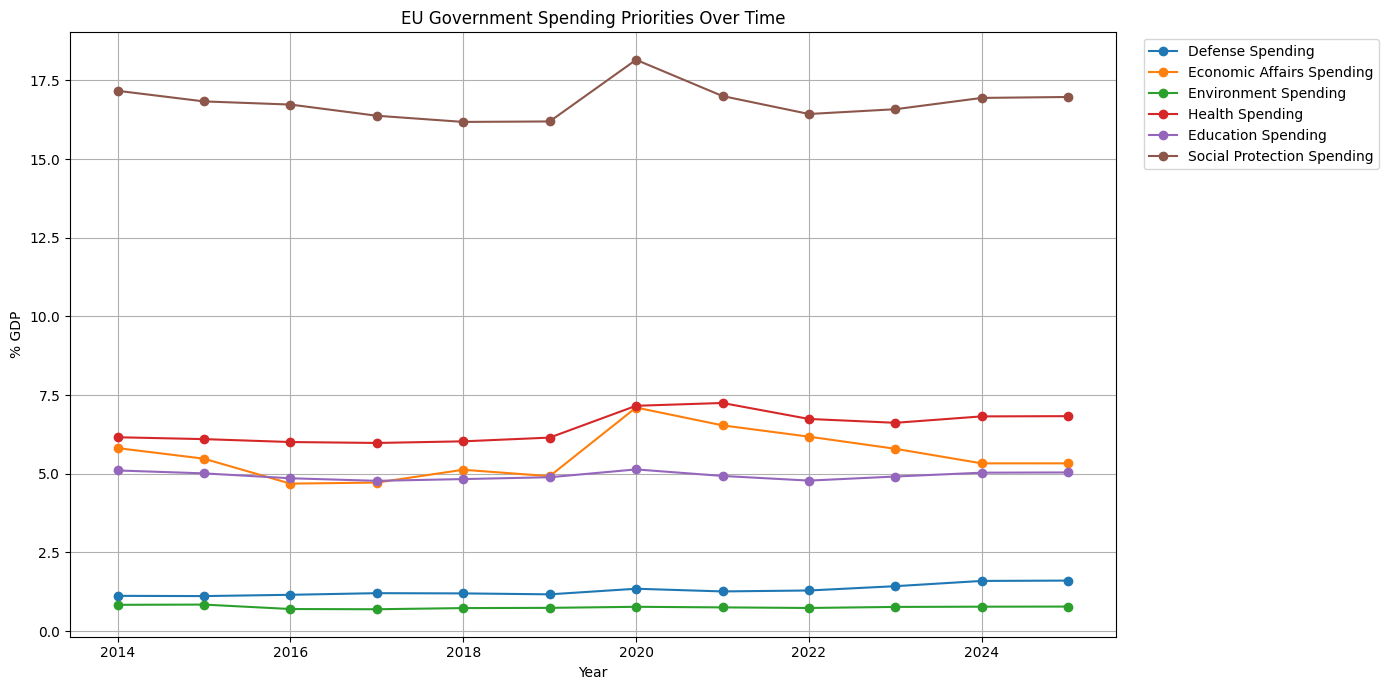

In [68]:
import matplotlib.pyplot as plt

# =========================================================
# EU AVERAGE SPENDING PRIORITIES OVER TIME
# =========================================================

spending_cols = [
    "defense_spending",
    "economic_affairs_spending",
    "environment_spending",
    "health_spending",
    "education_spending",
    "social_protection_spending"
]

# EU yearly averages
eu_spending_trends = (
    eu_master_plus
    .groupby("year")[spending_cols]
    .mean()
)

# Plot
plt.figure(figsize=(14, 7))

for col in spending_cols:

    plt.plot(
        eu_spending_trends.index,
        eu_spending_trends[col],
        marker="o",
        label=col.replace("_", " ").title()
    )

plt.title("EU Government Spending Priorities Over Time")

plt.xlabel("Year")
plt.ylabel("% GDP")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

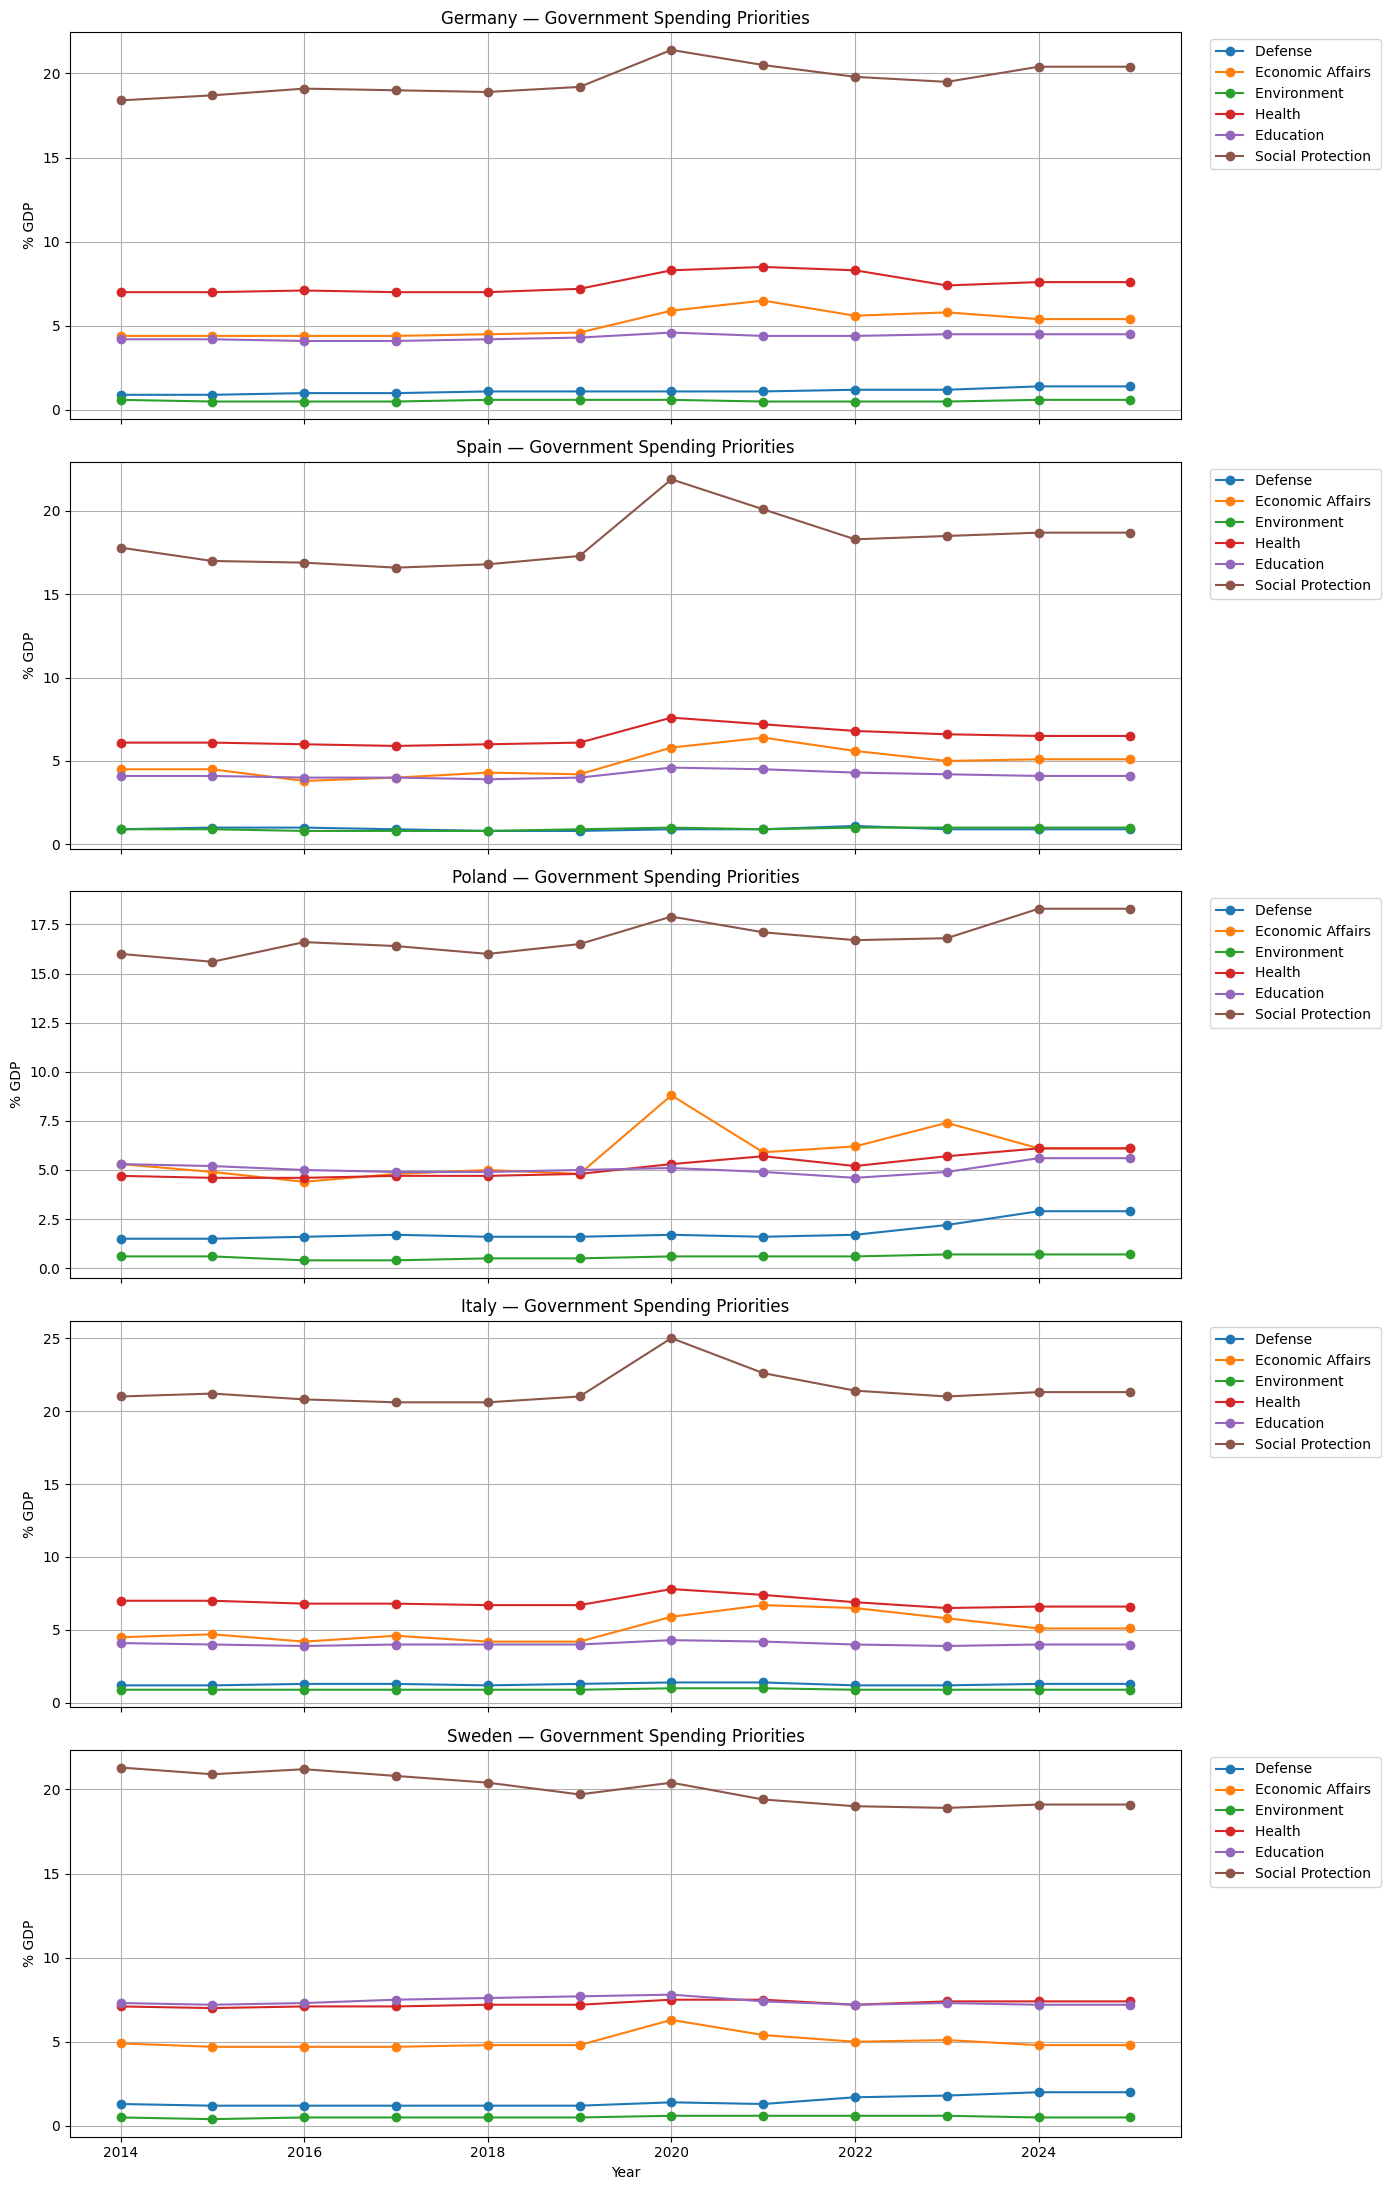

In [69]:
import matplotlib.pyplot as plt

# =========================================================
# CASE STUDY COUNTRIES
# =========================================================

case_countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

spending_cols = [
    "defense_spending",
    "economic_affairs_spending",
    "environment_spending",
    "health_spending",
    "education_spending",
    "social_protection_spending"
]

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(14, 22),
    sharex=True
)

for ax, (code, name) in zip(axes, case_countries.items()):

    country_df = (
        eu_master_plus[
            eu_master_plus["country"] == code
        ]
        .sort_values("year")
    )

    for col in spending_cols:

        ax.plot(
            country_df["year"],
            country_df[col],
            marker="o",
            label=col.replace("_", " ").replace("spending", "").title()
        )

    ax.set_title(f"{name} — Government Spending Priorities")

    ax.set_ylabel("% GDP")

    ax.grid(True)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.xlabel("Year")

plt.tight_layout()

plt.show()

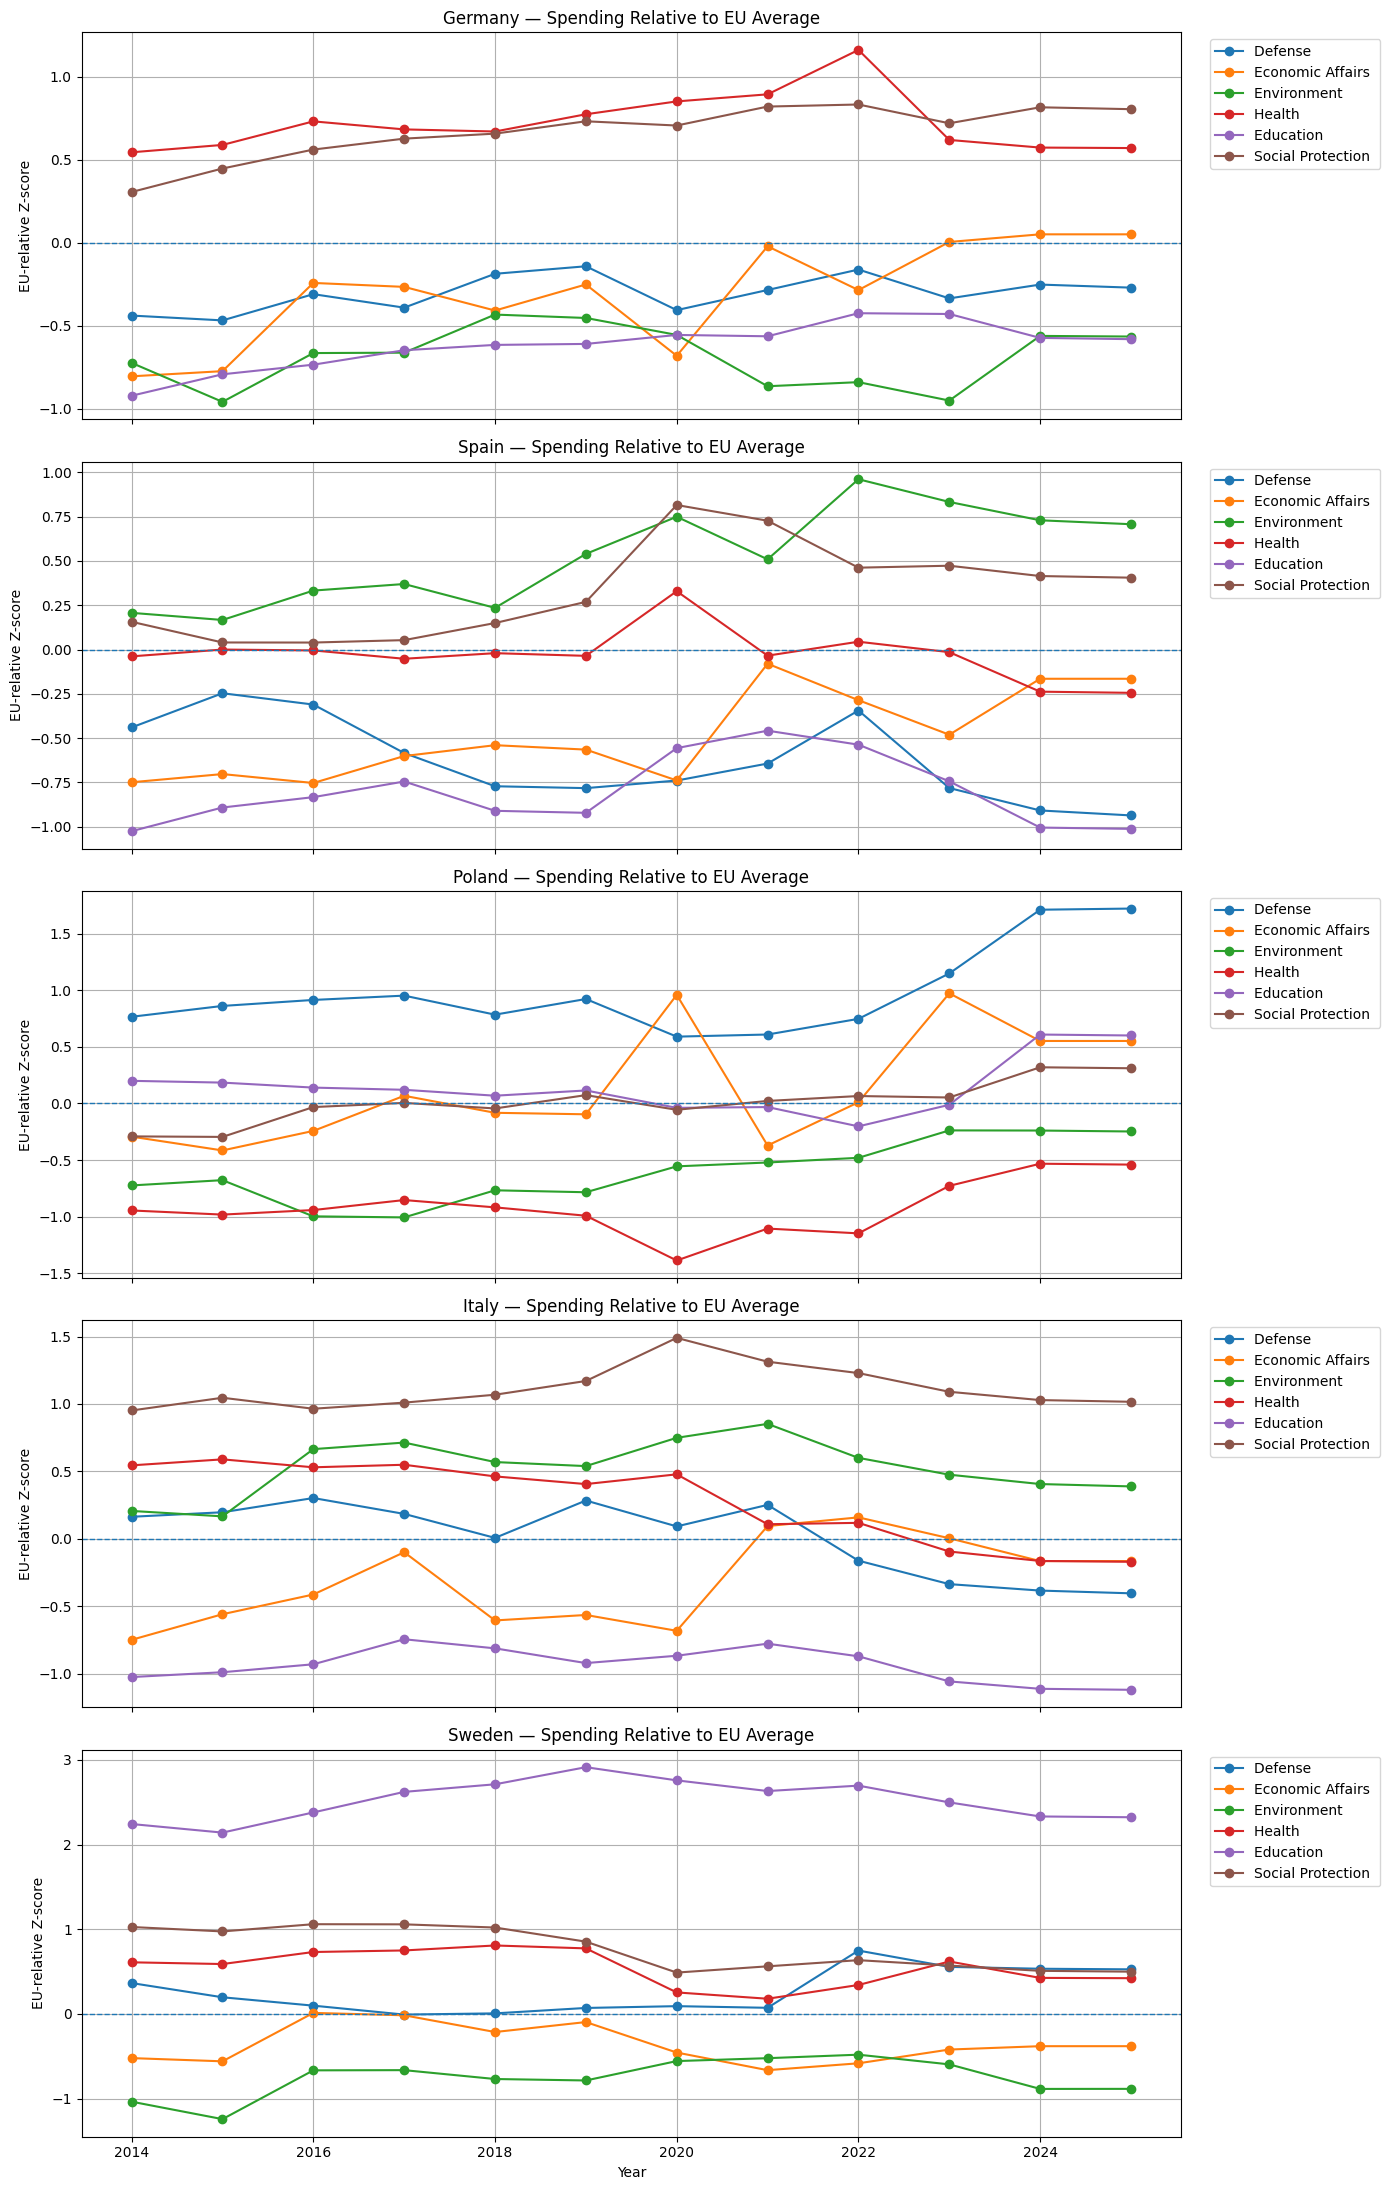

In [70]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

# =========================================================
# CASE STUDY COUNTRIES
# =========================================================

case_countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

spending_cols = [
    "defense_spending",
    "economic_affairs_spending",
    "environment_spending",
    "health_spending",
    "education_spending",
    "social_protection_spending"
]

# =========================================================
# EU-RELATIVE Z-SCORES
# normalize each KPI relative to EU distribution per year
# =========================================================

eu_relative = eu_master_plus.copy()

for col in spending_cols:

    eu_relative[f"{col}_z"] = (
        eu_relative
        .groupby("year")[col]
        .transform(zscore)
    )

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(14, 22),
    sharex=True
)

for ax, (code, name) in zip(axes, case_countries.items()):

    country_df = (
        eu_relative[
            eu_relative["country"] == code
        ]
        .sort_values("year")
    )

    for col in spending_cols:

        ax.plot(
            country_df["year"],
            country_df[f"{col}_z"],
            marker="o",
            label=col.replace("_", " ").replace("spending", "").title()
        )

    # EU average reference line
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(f"{name} — Spending Relative to EU Average")

    ax.set_ylabel("EU-relative Z-score")

    ax.grid(True)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.xlabel("Year")

plt.tight_layout()

plt.show()

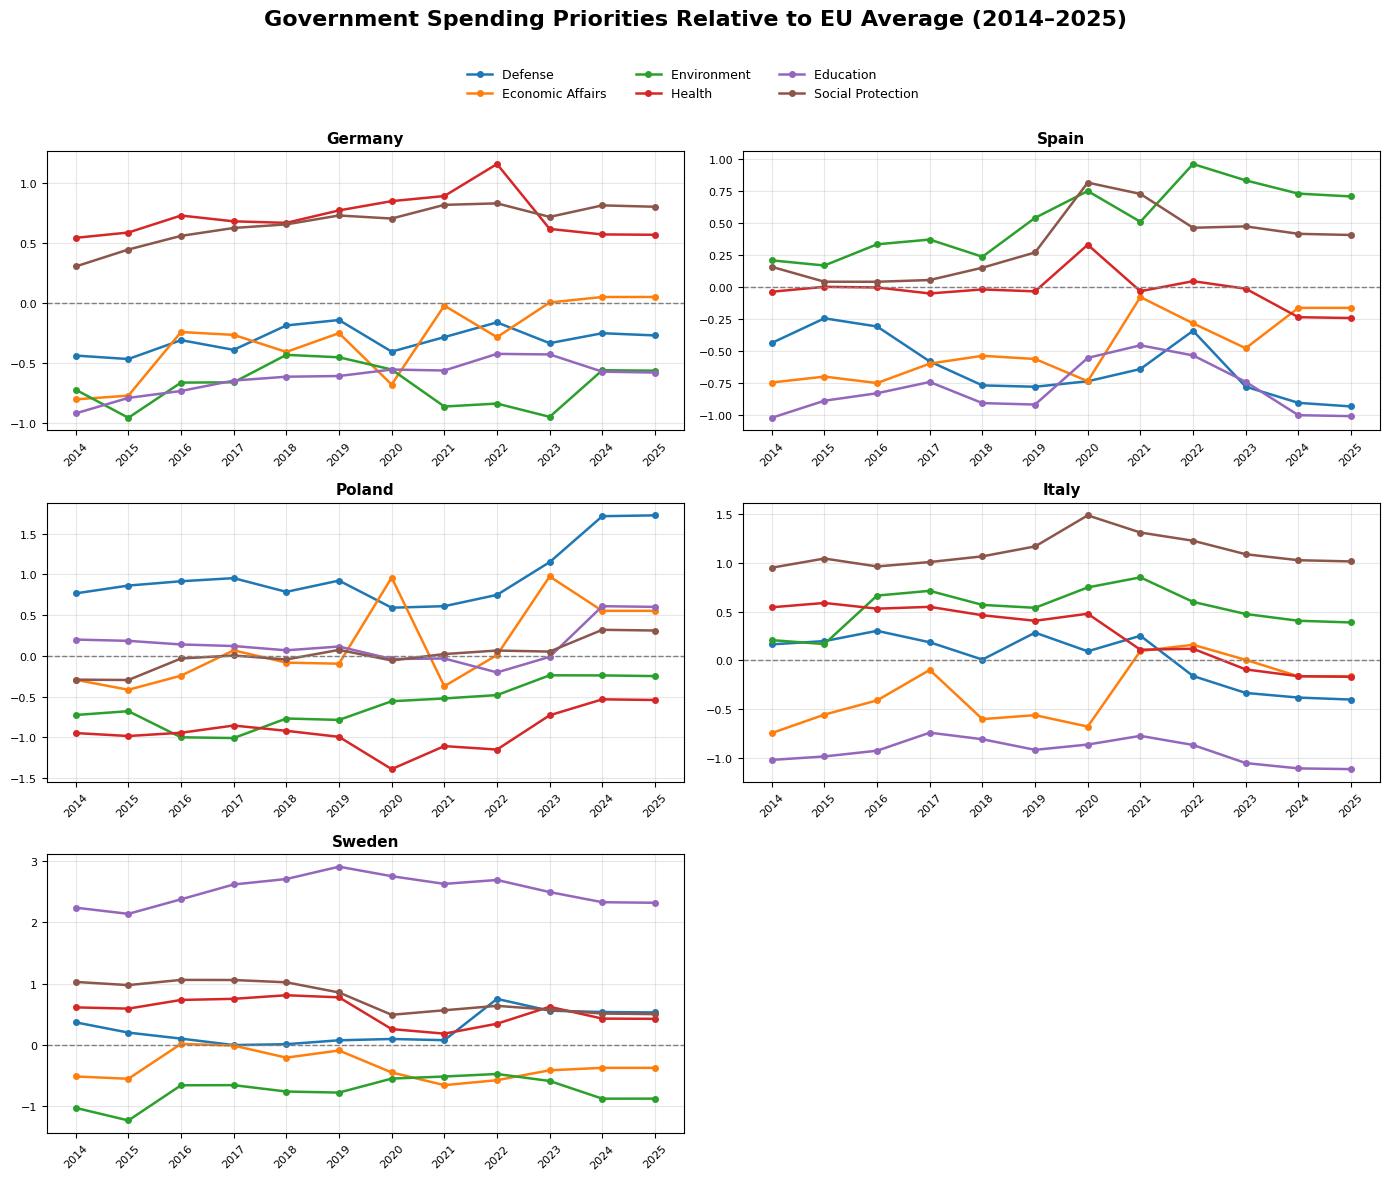

In [75]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

# =========================================================
# CASE STUDY COUNTRIES
# =========================================================

case_countries = {
    "DE": "Germany",
    "ES": "Spain",
    "PL": "Poland",
    "IT": "Italy",
    "SE": "Sweden"
}

spending_cols = [
    "defense_spending",
    "economic_affairs_spending",
    "environment_spending",
    "health_spending",
    "education_spending",
    "social_protection_spending"
]

# =========================================================
# EU-RELATIVE Z-SCORES
# normalize each KPI relative to EU distribution per year
# =========================================================

eu_relative = eu_master_plus.copy()

for col in spending_cols:

    eu_relative[f"{col}_z"] = (
        eu_relative
        .groupby("year")[col]
        .transform(zscore)
    )

# =========================================================
# COMPACT 2-COLUMN LAYOUT
# =========================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12),
    sharex=False
)

axes = axes.flatten()

for i, (code, name) in enumerate(case_countries.items()):

    ax = axes[i]

    country_df = (
        eu_relative[
            eu_relative["country"] == code
        ]
        .sort_values("year")
    )

    for col in spending_cols:

        ax.plot(
            country_df["year"],
            country_df[f"{col}_z"],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=col.replace("_", " ").replace("spending", "").title()
        )

    # EU average reference line
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        color="gray"
    )

    ax.set_title(
        f"{name}",
        fontsize=11,
        fontweight="bold"
    )

    # SHOW YEARS ON ALL PLOTS
    ax.set_xticks(country_df["year"])
    ax.tick_params(axis="x", rotation=45, labelsize=8)

    ax.tick_params(axis="y", labelsize=8)

    ax.grid(alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[-1])

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    "Government Spending Priorities Relative to EU Average (2014–2025)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# =========================================================
# SHARED LEGEND
# =========================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    fontsize=9,
    frameon=False
)

# =========================================================
# SPACING
# =========================================================

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

# Government Spending Archetypes — Absolute vs Relative EU Positioning

The spending analysis reveals that countries maintain relatively stable long-term policy allocation structures, while still responding differently to major external shocks such as COVID-19 and the post-2022 geopolitical transition.

Using both:
- absolute spending levels (% GDP)
- relative EU-normalized positioning (Z-score)

helps distinguish between:
- structural national models
- temporary crisis responses
- strategic divergence from the European average.

---

# Common EU-Wide Dynamics

Across nearly all countries:

- 2020 produced a clear spending shock:
  - health spending increased
  - economic affairs spending increased
  - social protection spending increased

This reflects the coordinated COVID fiscal response across Europe.

Post-2022:
- defense spending rises in many countries
- especially in Poland and Germany
- suggesting a broader geopolitical reprioritization after the Ukraine war.

At the same time:
- education spending remains relatively stable
- environmental spending changes gradually rather than abruptly,
suggesting these are treated as long-term structural priorities rather than short-term crisis tools.

---

# Germany — Balanced Industrial Transition Model

## Absolute Perspective
Germany maintains:
- stable social protection spending
- strong health investment
- moderate education spending
- relatively low but increasing defense spending

Environmental spending remains consistently present, while economic affairs spending spikes during COVID.

## Relative EU Position
Compared to the EU average:
- health and social protection are consistently above average
- environmental spending is below EU average
- defense spending remains below average despite recent increases
- economic affairs spending converges toward EU average after 2020

## Interpretation
Germany appears as:
- a stable industrial welfare state
- fiscally balanced
- transition-oriented rather than aggressively interventionist

The country emphasizes:
- resilience
- healthcare
- social stability
while maintaining moderate investment in sustainability and industrial transition.

---

# Spain — Welfare & Recovery-Oriented Structure

## Absolute Perspective
Spain shows:
- high social protection spending
- relatively high health expenditure
- lower defense spending
- lower education spending

COVID generated one of the strongest social spending spikes.

## Relative EU Position
Compared to the EU:
- environmental spending is consistently above average
- defense and education remain below average
- social protection remains above average
- economic affairs spending weakens after the COVID recovery period

## Interpretation
Spain appears strongly oriented toward:
- welfare stabilization
- recovery management
- social cushioning

rather than:
- security expansion
- industrial competitiveness
- fiscal assertiveness.

---

# Poland — Security & Growth Transition Model

## Absolute Perspective
Poland demonstrates:
- rapidly increasing defense spending
- high economic affairs spending
- lower environmental spending
- increasing education and social spending

The post-2022 defense acceleration is particularly visible.

## Relative EU Position
Compared to the EU:
- defense spending becomes dramatically above average
- economic affairs spending also rises strongly
- environmental and health spending remain below average
- education converges upward over time

## Interpretation
Poland shows the clearest strategic transition:
- security
- infrastructure
- industrial development
become dominant priorities.

The country appears to prioritize:
- resilience
- geopolitical preparedness
- economic expansion

over welfare-heavy allocation structures.

---

# Italy — Welfare-Heavy Structural Rigidity

## Absolute Perspective
Italy consistently exhibits:
- very high social protection spending
- relatively high health spending
- lower education investment
- modest defense growth

Spending structure changes relatively little over time.

## Relative EU Position
Compared to the EU:
- social protection remains structurally far above average
- education stays significantly below average
- environmental and health spending remain above average
- defense becomes below average after 2022

## Interpretation
Italy appears characterized by:
- mature welfare-state rigidity
- fiscal inertia
- limited strategic reallocation flexibility

The spending structure suggests:
- strong legacy obligations
- slower structural adaptation capacity.

---

# Sweden — Human Capital & Welfare Model

## Absolute Perspective
Sweden maintains:
- high education spending
- high health spending
- strong welfare baseline
- relatively low economic affairs spending

Defense spending increases after 2022 but remains moderate in absolute terms.

## Relative EU Position
Compared to the EU:
- education is dramatically above average
- health and welfare are consistently above average
- environmental spending is surprisingly below EU average relative to peers
- defense rises moderately after 2022

## Interpretation
Sweden represents:
- a human-capital intensive model
- strong welfare orientation
- long-term social investment strategy

Rather than relying heavily on direct economic intervention,
Sweden appears to emphasize:
- institutional quality
- education
- social resilience.

---

# Cross-Country Structural Archetypes

The combined analysis suggests five distinct strategic allocation models:

| Country | Dominant Structural Orientation |
|---|---|
| Germany | balanced industrial transition |
| Spain | welfare & recovery stabilization |
| Poland | security-growth transition |
| Italy | welfare-heavy structural rigidity |
| Sweden | human-capital welfare model |

---

# Overall Conclusion

The spending layer substantially strengthens the project because it introduces:

- explicit public priorities
- policy allocation structures
- crisis response dynamics
- geopolitical adaptation signals

The analysis now moves beyond:
- simple macroeconomic comparison

toward:
- comparative strategic systems analysis

where countries are interpreted as evolving structural models responding differently to:
- sustainability challenges
- economic shocks
- demographic pressures
- geopolitical transitions.

# EU Structural Transition & Policy Priorities Project — Current Status

## Core Dataset
Built a clean EU panel dataset:
- 27 EU countries
- 2014–2025
- 324 observations

Integrated structural KPIs:
- GDP growth
- inflation
- unemployment
- inequality (Gini)
- education
- R&D intensity
- ICT specialists
- renewables
- emissions
- debt

Missing values handled mainly via:
- country filtering
- forward-fill for 2025 gaps.

---

# Added Government Spending Layer (Eurostat COFOG)

Integrated public spending priorities (% GDP):
- defense spending
- economic affairs spending
- fuel & energy spending
- communication spending
- environmental spending
- health spending
- education spending
- social protection spending
- total government expenditure

This upgraded the project from:
- macro trend analysis

toward:
- comparative strategic systems analysis.

---

# Main Analytical Directions Explored

## 1. EU-Level Trends
Visualized:
- normalized KPI trajectories
- long-term structural transitions
- COVID shock effects
- post-2022 geopolitical shifts

Observed:
- renewables increasing
- emissions decreasing
- ICT specialization increasing
- debt spike during COVID
- inflation shock after 2021.

---

## 2. Country Archetypes
Focused on:
- Germany
- Spain
- Poland
- Italy
- Sweden

Identified distinct structural models:
- Germany → balanced industrial transition
- Spain → welfare/recovery orientation
- Poland → security-growth transition
- Italy → welfare-heavy rigidity
- Sweden → human-capital welfare model

---

## 3. Relative EU Positioning
Normalized spending and KPIs relative to EU averages (Z-score).

This revealed:
- strategic divergence between countries
- persistent national allocation structures
- different responses to crises and geopolitical events.

---

## 4. Tradeoff & Trajectory Analysis
Built:
- correlation heatmaps
- transition trajectory plots
- spending vs outcome relationships

Examples:
- renewables vs emissions
- environment spending vs renewables
- defense growth after Ukraine war
- welfare vs investment structures

Focus is on:
- associations
- structural patterns
- comparative trajectories

NOT causal claims.

---

# Project Framing

Current project direction:

```text
Government priorities
→ structural indicators
→ macro trajectories
→ country archetypes & tradeoffs

In [71]:
# =========================================================
# SAVE FINAL DATASETS
# =========================================================

import os

# Output folder
output_path = r"C:\Users\gilad\Documents\Data Analytics course 02_26\capston project\possible data\processed"

# Create folder if it does not exist
os.makedirs(output_path, exist_ok=True)

# 1. Save government spending table
gov_wide.to_csv(
    os.path.join(output_path, "government_spending_wide.csv"),
    index=False
)

# 2. Save final merged master dataset
eu_master_plus.to_csv(
    os.path.join(output_path, "eu_master_plus.csv"),
    index=False
)

# 3. Optional: save Excel version for easy inspection
eu_master_plus.to_excel(
    os.path.join(output_path, "eu_master_plus.xlsx"),
    index=False
)

# Validate saved files
print("Saved files:")
print(os.listdir(output_path))

Saved files:
['eu_master_plus.csv', 'eu_master_plus.xlsx', 'government_spending_wide.csv']
